<a href="https://colab.research.google.com/github/evgenykomarov/sdc_course/blob/spring2026/Prediction_planning_homework.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Установка пакетов и загрузка данных для ноутбука

Для работы нам понадобится установить пакет `waymax` https://github.com/waymo-research/waymax


Waymax -- симулятор для исследования автономного вождения, базирующийся на `Waymo Open Motion Dataset` https://github.com/waymo-research/waymo-open-dataset

Для обучения сетки будем использовать
`Pytorch Lightning` https://lightning.ai/docs/pytorch/

Для запуска на GPU нужно сменить среду выполнения на Графический процессор

Устанавливаем пакеты:

In [105]:
import sys
print(f"Python: {sys.executable}")
print(f"Version: {sys.version}")

Python: /home/evgenykomarov/.pyenv/versions/3.12.13/envs/waymax_fresh/bin/python
Version: 3.12.13 (main, May 19 2026, 09:13:30) [GCC 11.4.0]


In [106]:
# !export ALL_PROXY=socks5h://127.0.0.1:1080
# !export HTTP_PROXY=socks5h://127.0.0.1:1080
# !export HTTPS_PROXY=socks5h://127.0.0.1:1080

In [107]:
# import os
# os.environ['HTTPS_PROXY'] = 'socks5h://127.0.0.1:1080'
# os.environ['HTTP_PROXY']  = 'socks5h://127.0.0.1:1080'
# os.environ['ALL_PROXY']   = 'socks5h://127.0.0.1:1080'

In [108]:
# !pip install --upgrade pip
# # Install waymax, which will bring in jax and jaxlib (version 0.7.2).
# # jaxlib 0.7.2 requires numpy>=2.0.
# !pip install git+https://github.com/waymo-research/waymax.git@main#egg=waymo-waymax

# # Explicitly install numpy 2.0.0 to satisfy jaxlib's requirement.
# # This ensures a numpy 2.x version is used.
# # !pip install numpy==2.4.4

# # Install matplotlib 3.9.0, which is compatible with numpy 2.0.0.
# # !pip install matplotlib==3.10.9

# # pytorch-lightning 2.5.0 is compatible with numpy 2.0.0.
# # !pip install pytorch-lightning==2.6.1
# !pip install pytorch-lightning==2.1.3

Необходимые для семинара данные и код лежат по ссылке https://drive.google.com/drive/folders/1iI_1PIFNx6-5MUIQkjslg1MqRhP7mikM?usp=sharing

Необходимо создать ярлык на своем Google Drive

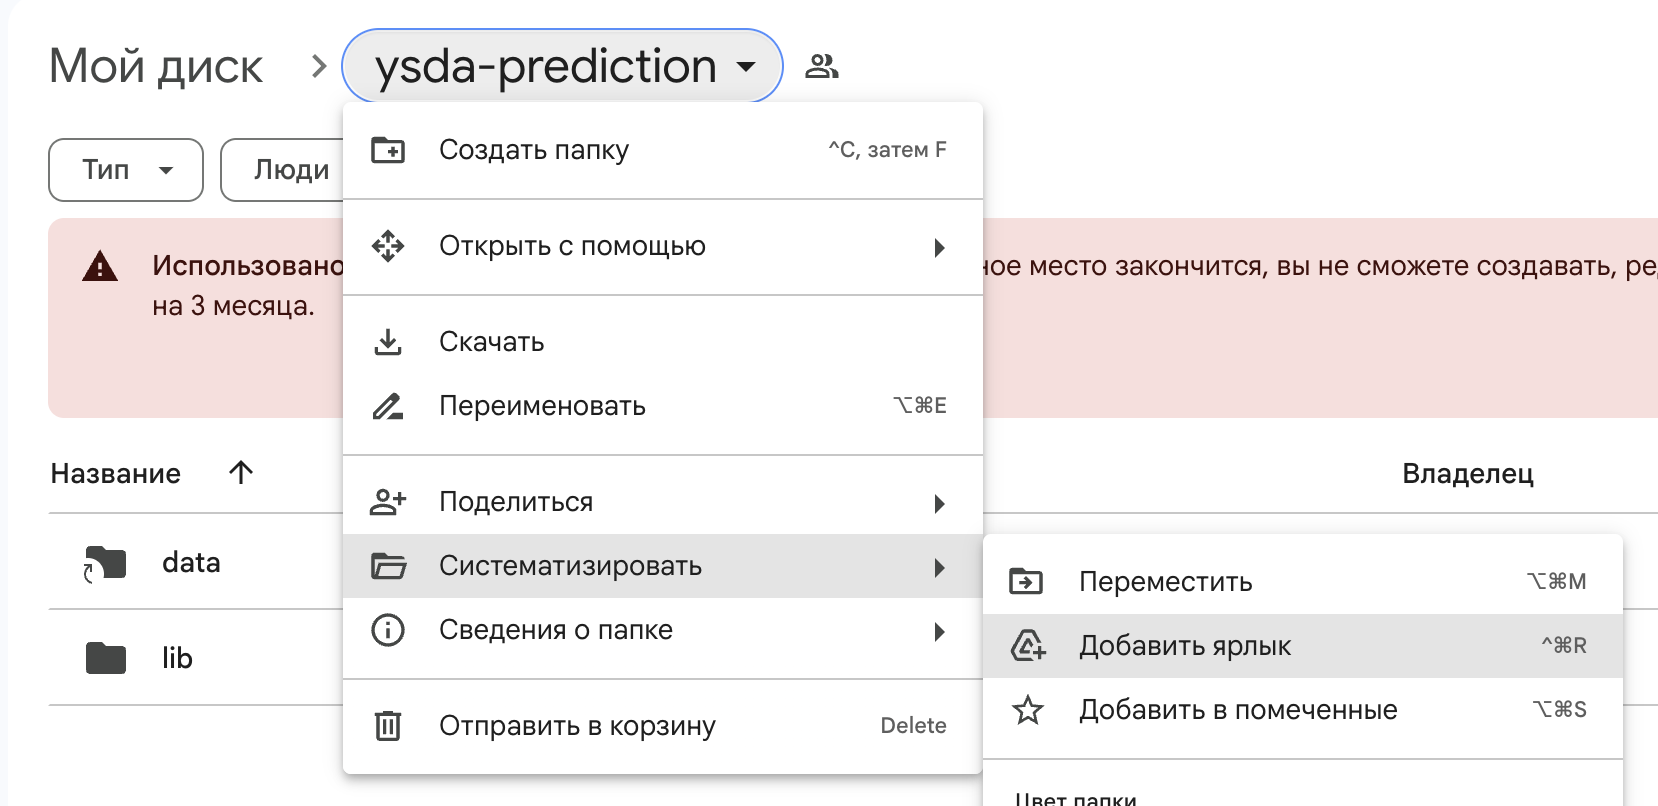

Монтируем гугл диск в локальную файловую систему

In [109]:
# from google.colab import drive
# drive.mount('/content/drive')

Ниже нужно указать путь до созданного ранее ярлыка, например, если ярлык имеет путь `ai360`, то должно получиться
```
SEMINAR_PATH = '/content/drive/MyDrive/ai360'
```

In [110]:
# SEMINAR_PATH = '/content/drive/MyDrive/ysda/self-driving-cars/ysda-prediction'

In [111]:
# !wget -O data.tar.gz "$(curl -s "https://cloud-api.yandex.net/v1/disk/public/resources/download?public_key=https://disk.yandex.ru/d/vHocpJM-oTCj-A" | jq -r .href)"
# # !mkdir ysda-prediction
# !tar -xf data.tar.gz -C '/content/drive/MyDrive/ysda/self-driving-cars/ysda-prediction'

Копируем себе в локальное файловое пространство папки с полезными функциями

In [112]:
import os
import shutil

# if not os.path.exists('lib'):
#     shutil.copytree(os.path.join(SEMINAR_PATH, 'lib'), 'lib')
# else:
#     print('"lib" folder already exists. If you want to rewrite lib by original folder, remove local "lib" manually')

assert os.path.exists('lib')

Импортируем библиотеки

In [113]:
# !pip install mediapy
# !pip install torch
# !pip install shapely
# !pip install pyparsing
# !pip install cycler
# !pip install cycler
# !pip install pytorch_lightning
# !pip install toolz

In [114]:
%%capture

import os
import sys
import shutil
import subprocess
import time
from datetime import datetime

from copy import deepcopy
from typing import Any, Optional, Callable, Sequence
from collections import defaultdict
import dataclasses

import shapely

import mediapy
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader

import jax
from jax import numpy as jnp
from jax import random

import pytorch_lightning as pl
from pytorch_lightning.loggers import TensorBoardLogger
from pytorch_lightning.callbacks import ModelCheckpoint, TQDMProgressBar

from waymax.config import DatasetConfig
from waymax import visualization
from waymax import datatypes
from waymax import config as _config
from waymax import dataloader
from waymax import dynamics
from waymax import metrics
from waymax import env as _env
from waymax import agents
from waymax.agents import SimAgentActor, WaymaxActorOutput

import chex

from tqdm import tqdm


from lib.data_utils import WaymaxDataset, scenario_to_features_gt


# Use CUDA for hw
device = 'cuda'
# device = 'cpu'
render_size = 200


С помощью следующей функции генерируем конфиг для подгрузки датасета

In [115]:
SEMINAR_PATH = './data'

In [116]:
def get_data_config(split_name, seminar_path=SEMINAR_PATH):
    split_path = os.path.join(SEMINAR_PATH, 'data', split_name)

    obj_count = int(os.listdir(split_path)[0].rsplit('-')[-1])
    return DatasetConfig(
        path=os.path.join(split_path, f'{split_name}_tfexample.tfrecord@{obj_count}'),
        max_num_objects=24,
        batch_dims=[8],
        repeat=1,
        shuffle_buffer_size=64,
        deterministic=False,
        num_shards=1
    )

Создаем датасеты для разных сплитов

In [117]:
train_dataset = WaymaxDataset(get_data_config('training'))
val_dataset = WaymaxDataset(get_data_config('validation'))

In [118]:
FUTURE_STEPS = 30  # Predict 3 seconds,  10Hz frequency

In [119]:
%%capture
scenario = next(iter(train_dataset))
features, gt = scenario_to_features_gt(scenario)

In [120]:
features.keys()

dict_keys(['log_trajectory', 'sim_trajectory', 'log_traffic_light', 'object_metadata', 'roadgraph_points', 'agent_to_predict_mask'])

# Задания

## 1. Нормализация сцены [3 балла]

Баллы начисляются бинарно(0 или 3) за прохождение теста

Нужно реализовать функции, позволяющие перевести сцену в локальную систему координат агента, которого предсказываем. Данного агента можно вычленить с помощью маски `agent_to_predict_mask`

In [121]:
features['agent_to_predict_mask'].shape

torch.Size([8, 24])

In [122]:
features['log_trajectory'].keys()

dict_keys(['x', 'y', 'z', 'vel_x', 'vel_y', 'yaw', 'valid', 'timestamp_micros', 'length', 'width', 'height'])

In [123]:
features['sim_trajectory'].keys()

dict_keys(['x', 'y', 'z', 'vel_x', 'vel_y', 'yaw', 'valid', 'timestamp_micros', 'length', 'width', 'height'])

In [124]:
features['log_traffic_light'].keys()

dict_keys(['x', 'y', 'z', 'state', 'lane_ids', 'valid'])

In [125]:
features['roadgraph_points'].keys()

dict_keys(['x', 'y', 'z', 'dir_x', 'dir_y', 'dir_z', 'types', 'ids', 'valid'])

In [126]:
features['log_trajectory']['x'].shape

torch.Size([8, 24, 11])

In [127]:
agent_to_predict_mask = features['agent_to_predict_mask'] # [bs, 24]
agent_to_predict_mask.shape

torch.Size([8, 24])

In [128]:
xs = features['log_trajectory']['x'][..., -1][agent_to_predict_mask]
ys = features['log_trajectory']['y'][..., -1][agent_to_predict_mask]
yaws = features['log_trajectory']['yaw'][..., -1][agent_to_predict_mask]
xs.shape, ys.shape, yaws.shape

(torch.Size([8]), torch.Size([8]), torch.Size([8]))

In [129]:
yaws

tensor([-3.1337, -3.1361, -1.9279,  3.1362, -0.4134, -1.5718,  1.5741,  0.0198])

Для удобного перевода в систему координат агента сделаем обертку модели, которая нормализует сцену, делает предсказание в новой системе координат и после применяет обратное преобразования для предсказаний.


Реализуйте методы класса

In [130]:
class NormalizeSceneWrapper(nn.Module):
    """
    Wrap model with features normalization and predictions denormalozation
    """

    def __init__(self, model):
        """
        Args:
          model: model to wrap
        """
        super().__init__()
        self.model = model


    @staticmethod
    def extract_anchor_x_y_yaw(features):
        """
        Take anchor coordinates as coordinates of agent to predict in last tick

        Args:
          features: features in global space

        Return:
          anchor: tuple containing (anchor_x, anchor_y, anchor_yaw)
                anchor_x: [bs] x coord of target agent per batch
                anchor_y: [bs] y coord of target agent per batch
                anchor_yaw: [bs] yaw of target agent per batch
        """
        # YOUR CODE HERE
        agent_to_predict_mask = features['agent_to_predict_mask'] # [bs, 24]
        anchor_x = features['log_trajectory']['x'][..., -1][agent_to_predict_mask]
        anchor_y = features['log_trajectory']['y'][..., -1][agent_to_predict_mask]
        anchor_yaw = features['log_trajectory']['yaw'][..., -1][agent_to_predict_mask]
        return anchor_x, anchor_y, anchor_yaw


    @staticmethod
    def affine(x, y, x0, y0, angle):
        assert x.shape[0] == x0.shape[0] # batch_size
        view_shape = [-1] + [1] * (x.ndim - 1)
        x_prime =  (x - x0.view(*view_shape)) * torch.cos(angle).view(*view_shape) + (y - y0.view(*view_shape)) * torch.sin(angle).view(*view_shape)
        y_prime = -(x - x0.view(*view_shape)) * torch.sin(angle).view(*view_shape) + (y - y0.view(*view_shape)) * torch.cos(angle).view(*view_shape)
        return x_prime, y_prime

    @staticmethod
    def inverse_affine(x_prime, y_prime, x0, y0, angle):
        assert x_prime.shape[0] == x0.shape[0] # batch_size
        view_shape = [-1] + [1] * (x_prime.ndim - 1)
        x = x0.view(*view_shape) + x_prime * torch.cos(angle).view(*view_shape) - y_prime * torch.sin(angle).view(*view_shape)
        y = y0.view(*view_shape) + x_prime * torch.sin(angle).view(*view_shape) + y_prime * torch.cos(angle).view(*view_shape)
        return x, y

    @staticmethod
    def affine1(x, y, x0, y0, angle):
        assert x.shape[0] == x0.shape[0] # batch_size
        x_prime =  (x - x0) * torch.cos(angle) + (y - y0) * torch.sin(angle)
        y_prime = -(x - x0) * torch.sin(angle) + (y - y0) * torch.cos(angle)
        return x_prime, y_prime

    @staticmethod
    def inverse_affine1(x_prime, y_prime, x0, y0, angle):
        assert x_prime.shape[0] == x0.shape[0] # batch_size
        x = x0 + x_prime * torch.cos(angle) - y_prime * torch.sin(angle)
        y = y0 + x_prime * torch.sin(angle) + y_prime * torch.cos(angle)
        return x, y

    @staticmethod
    def affine_inplace(dic, x0_, y0_, angle, mode):
        assert mode in set(['coordinate', 'velocity', 'direction', 'angle'])
        if mode == 'coordinate':
            prefix = ''
            x0, y0 = x0_, y0_
        elif mode == 'velocity':
            prefix = 'vel_'
            x0, y0 = x0_ * 0.0, y0_ * 0.0
        elif mode == 'direction':
            prefix = 'dir_'
            x0, y0 = x0_ * 0.0, y0_ * 0.0
        elif mode == 'angle':
            dic['yaw'] -= angle.view(-1, 1, 1)
            return
        else:
            raise Exception

        x_key = prefix + 'x'
        y_key = prefix + 'y'
        assert x_key in dic
        assert y_key in dic
        dic[x_key], dic[y_key] = NormalizeSceneWrapper.affine(dic[x_key], dic[y_key], x0, y0, angle)


    @staticmethod
    def affine_inverse_inplace(dic, x0_, y0_, angle, mode):
        assert mode in set(['coordinate', 'velocity', 'direction', 'angle'])
        if mode == 'coordinate':
            prefix = ''
            x0, y0 = x0_, y0_
        elif mode == 'velocity':
            prefix = 'vel_'
            x0, y0 = x0_ * 0.0, y0_ * 0.0
        elif mode == 'direction':
            prefix = 'dir_'
            x0, y0 = x0_ * 0.0, y0_ * 0.0
        elif mode == 'angle':
            dic['yaw'] += angle.view(-1, 1, 1)
            return
        else:
            raise Exception

        x_key = prefix + 'x'
        y_key = prefix + 'y'
        assert x_key in dic
        assert y_key in dic
        dic[x_key], dic[y_key] = NormalizeSceneWrapper.inverse_affine(dic[x_key], dic[y_key], x0, y0, angle)

    @staticmethod
    def copy_dict_by_keys(dict_of_tensors, key_debug=None):
        assert isinstance(dict_of_tensors, dict)
        assert all([isinstance(dict_of_tensors[key], torch.Tensor) for key in dict_of_tensors])
        result = dict.fromkeys(dict_of_tensors.keys())
        for key, value in dict_of_tensors.items():
            result[key] = value.clone().detach()
        return result

    @staticmethod
    def transform_features_to_agent_space(features, anchor_x, anchor_y, anchor_yaw):
        """
        Transform features to agent space, using anchor of agent space
        Transform all elements of features, including
        `log_trajectory`, `sim_trajectory`, `log_traffic_light` and `roadgraph_points`


        Args:
          features: features in global space
          anchor_x: [bs] x coord of anchor agent
          anchor_y: [bs] y coord of anchor agent
          anchor_yaw: [bs] yaw of anchor agent

        Return:
          features: features in agent space
        """
        # YOUR CODE HERE
        features_prime = {}
        for key in features.keys():
            if isinstance(features[key], torch.Tensor):
                features_prime[key] = features[key].clone().detach()
                continue
            if isinstance(features[key], datatypes.object_state.ObjectMetadata):
                features_prime[key] = features[key]
                continue

            features_prime[key] = NormalizeSceneWrapper.copy_dict_by_keys(features[key], key_debug=key)

            if 'x' in features_prime[key]:
                mode = 'coordinate'
                NormalizeSceneWrapper.affine_inplace(features_prime[key], anchor_x, anchor_y, anchor_yaw, mode)

            if 'vel_x' in features_prime[key]:
                mode = 'velocity'
                NormalizeSceneWrapper.affine_inplace(features_prime[key], anchor_x, anchor_y, anchor_yaw, mode)

            if 'dir_x' in features_prime[key]:
                mode = 'direction'
                NormalizeSceneWrapper.affine_inplace(features_prime[key], anchor_x, anchor_y, anchor_yaw, mode)

            if 'yaw' in features_prime[key]:
                mode = 'angle'
                NormalizeSceneWrapper.affine_inplace(features_prime[key], anchor_x, anchor_y, anchor_yaw, mode)

        assert set(list(features_prime.keys())) - set(list(features.keys())) == set([])
        for key in features_prime:
            if not hasattr(features_prime[key], 'keys'):
                continue
            assert all([features_prime[key][k].shape == features[key][k].shape for k in features_prime[key].keys()])


        # from pdb import set_trace
        # set_trace()


        return features_prime

    @staticmethod
    def transform_predictions_from_agent_space(pred, anchor_x, anchor_y, anchor_yaw):
        """
        Transform predictions to global space, using anchor of agent space
        Transform all elements of prediction, including
        `/trajectory/x`, `/trajectory/y`, `/trajectory/yaw`,
        `/trajectory/vel_x` and `/trajectory/vel_y`


        Args:
          pred: predictions in agent space, see SimpleModel for format
          anchor_x: [bs] x coord of anchor agent
          anchor_y: [bs] y coord of anchor agent
          anchor_yaw: [bs] yaw of anchor agent

        Return:
          pred: predictions in global space
          pred = {
            'trajectory': {
                'x': traj[..., 0],
                'y': traj[..., 1],
                'yaw': torch.atan2(traj[..., 2], traj[..., 3]),
                'vel_x': traj[..., 4],
                'vel_y': traj[..., 5]
            },
            'logits': ...
          }
        """
        # YOUR CODE HERE
        # TODO: x0 = 0, y0 = 0 for velocity mode
        assert set(list(pred.keys())) == set(['trajectory', 'logits'])
        assert set(list(pred['trajectory'].keys())) == set(['x', 'y', 'vel_x', 'vel_y', 'yaw', ])
        for mode in ['coordinate', 'velocity', 'angle', ]:
            NormalizeSceneWrapper.affine_inverse_inplace(pred['trajectory'], anchor_x, anchor_y, anchor_yaw, mode)

        return pred


    def forward(self, features, *args, **kwargs):
        """
        Transform features to target agent space,
        run model and transform predictions to original space

        Args:
          features: features in global space

        Returns:
          pred: pred of model in global space
        """
        # Select anchor coordinates of local space
        anchor_x, anchor_y, anchor_yaw = NormalizeSceneWrapper.extract_anchor_x_y_yaw(features)

        # Transform features to agent space
        new_features = NormalizeSceneWrapper.transform_features_to_agent_space(
            features,
            anchor_x,
            anchor_y,
            anchor_yaw
        )

        # Run model
        pred = self.model(new_features, *args, **kwargs)

        # Transform predictions from agent space to global space
        pred = NormalizeSceneWrapper.transform_predictions_from_agent_space(
            pred,
            anchor_x,
            anchor_y,
            anchor_yaw
        )

        return pred

In [131]:
from lib.tests.tests import test_normalize_wrapper

Tecт на 3 балла

In [132]:
test_normalize_wrapper(NormalizeSceneWrapper)

Normalize wrapper test passed


Ниже приведена немного измененная модель с семинара и показан пример ее использования вместе со враппером

In [133]:
class SimpleModel(nn.Module):
    def __init__(
            self,
            hidden_dim=128,
            history_size=11,
            n_modes=6,
            future_steps=FUTURE_STEPS
    ):
        """
        Simple model

        """
        super().__init__()
        self.layers = nn.Sequential(
            # x 7 is for ['x', 'y', 'vel_x', 'vel_y', 'length', 'width', 'valid', ]
            # + 1 is for  agent_type (vehicle, pedestrian, cyclist etc)
            nn.Linear(history_size * 7 + 1, hidden_dim),
            nn.ReLU(),
            # x 6 is for ['x', 'y', 'yaw', 'vel_x', 'vel_y', 'valid', ]
            # + n_modes to predict logits for each mode
            nn.Linear(hidden_dim, future_steps * n_modes * 6 + n_modes)
        )
        self.future_steps = future_steps
        self.n_modes = n_modes

    def __call__(self, features):
        bs, n_a, n_t = features['log_trajectory']['x'].shape

        # Make agent history features
        agents_history = torch.stack(
            [
                features['log_trajectory']['x'],
                features['log_trajectory']['y'],
                features['log_trajectory']['vel_x'],
                features['log_trajectory']['vel_y'],
                features['log_trajectory']['length'],
                features['log_trajectory']['width'],
                features['log_trajectory']['valid'],
            ],
            axis=-1
        )

        # Take interesting agent features
        agent_history = agents_history[features['agent_to_predict_mask']]
        agent_history = agent_history.reshape(bs, -1)

        # Add agent_type feature to features
        agent_type = features['object_metadata']['object_types'][features['agent_to_predict_mask']]
        agent_features = torch.cat(
            [agent_history, agent_type[..., None]], dim=-1)


        # Make prediction
        res = self.layers(agent_features)

        logits = res[..., -self.n_modes:]
        traj = res[..., :-self.n_modes].reshape(logits.shape[0], self.n_modes, self.future_steps, 6)

        res = {
            'trajectory': {
                'x': traj[..., 0],
                'y': traj[..., 1],
                'yaw': torch.atan2(traj[..., 2], traj[..., 3]),
                'vel_x': traj[..., 4],
                'vel_y': traj[..., 5]
            },
            'logits': logits
        }

        return res

In [134]:
model = NormalizeSceneWrapper(SimpleModel())
res = model(features)

## 2. Генерация растровых фичей [5 баллов]

- PixelTransformer [1 балл]
- AgentRenderer [2 балла]
- RoadGraphRenderer [1 балла]
- TrafficLightRenderer [1 балла]


В данной секции мы хотим взять векторные признаки и превратить их в растровую картинку. Отдельно напишем рендереры для траектории, карты и светофоров

In [135]:
import importlib
import lib.tests.tests
importlib.reload(lib.tests.tests)

from lib.tests.tests import (
    test_agent_renderer,
    test_roadgraph_renderer,
    test_traffic_light_renderer,
    test_pixel_transformer
)

In [136]:
def plot_feature_map(feature_map, batch_idx=2):
    for i in range(feature_map.shape[1]):
        plt.figure(figsize=(10, 10))
        plt.title(f'Channel {i}, empty={feature_map[batch_idx][i].sum() == 0}')
        plt.imshow(-feature_map[batch_idx][i].cpu(), cmap="gray", origin='lower')
        plt.show()

In [137]:
features, gt = scenario_to_features_gt(scenario, map_points=2048)

Векторизовывать мы будем уже центрированные в интересующем агенте признаки

(Если у Вас не сделан предыдущий пункт, то для дебага можете подгрузить данные из `lib/tests/data/transformed_features`)

In [138]:
ego_space_features = NormalizeSceneWrapper.transform_features_to_agent_space(
    features,
    *NormalizeSceneWrapper.extract_anchor_x_y_yaw(features)
)

Для начала реализуем класс, который будет переводить координаты в векторных фичах в координату пикселя на фичемапе. Предлагается пользоваться им для написания всех рендереров

In [139]:
class PixelTransformer:
    def __init__(self, size, resolution):
        """
        Transform coordinates between ordinary coordinates and feature map pixel index

        Args:
          size: length and width of feature map in pixels
          resolution: length and width of every pixel in meters


        """

        self.size = size
        self.resolution = resolution

        self.center_pixel = size // 2

        self.BIG_VALUE = size * resolution / 2
        self.OTHER_BIG_VALUE = size

    @staticmethod
    def linear(x, x0, y0, x1, y1):
        """
        rescales x s.t. y(x1) == x1 and y(x0) == y0
        y(x) = y1 + (x - x1) * (y1 - y0) / (x1 - x0)
        """
        return y1 + (x - x1) * (y1 - y0) / (x1 - x0)

    def to_pixel(self, x, y):
        """
        Transform from ordinary coordinates to feature map pixel index
        Assume (x=0, y=0) -> (ix=self.center_pixel, iy=self.center_pixel)
        Assume (x=-BIG_VALUE, y=-BIG_VALUE) -> (ix=0, iy=0)

        Args:
          x: x coordinates of arbitrary shape
          y: y coordinates of arbitrary shape

        Return:
          tuple with two elements `(ix, iy)` where ix and iy are coordinates on feature map
        """

        # YOUR CODE HERE
        center = self.center_pixel
        ix = PixelTransformer.linear(x, 0, center, -self.BIG_VALUE, 0)
        iy = PixelTransformer.linear(y, 0, center, -self.BIG_VALUE, 0)

        return torch.round(ix), torch.round(iy)

    def to_coord(self, ix, iy):
        """
        Transform from feature map pixel index to ordinary coords
        Assume (ix=self.center_pixel, iy=self.center_pixel) -> (x=0, y=0)
        Assume (ix=-size, iy=-size) -> (x=-BIG_VALUE, y=-BIG_VALUE)

        Args:
          ix: x pixel indices of arbitrary shape
          iy: y pixel indices of arbitrary shape

        Return:
          tuple with two elements `(x, y)` where x and y are ordinary coordinates
        """
        # YOUR CODE HERE
        center = self.center_pixel
        x = PixelTransformer.linear(ix, center, 0, 0, -self.BIG_VALUE)
        y = PixelTransformer.linear(iy, center, 0, 0, -self.BIG_VALUE)

        return x, y

    def to_clipped_pixel(self, x, y):
        """
        Transform from ordinary coordinates to feature map pixel index
        Assume that (x=0, y=0) -> (ix=self.center_pixel, iy=self.center_pixel)
        Assume (x=-BIG_VALUE, y=-BIG_VALUE) -> (ix=0, iy=0)

        If pixel coordinates ix or iy is out of range for feature map
        clip coords to closest valid value

        Args:
          x: x coordinates of arbitrary shape
          y: y coordinates of arbitrary shape

        Return:
          tuple with two elements `(ix, iy)` where ix and iy are clipped coordinates on feature map
        """
        # YOUR CODE HERE
        ix, iy = self.to_pixel(x, y)
        ix = torch.clamp(ix, min=0, max=self.size - 1)
        iy = torch.clamp(iy, min=0, max=self.size - 1)

        return ix, iy

    def is_valid_coords(self, x, y):
        """
        Check if feature map pixel index after transform
        is inside feature map range
        Assume that (x=0, y=0) -> (mask=True)
        Assume (x=-BIG_VALUE, y=-BIG_VALUE) -> (mask=False)


        Args:
          x: x coordinates of arbitrary shape
          y: y coordinates of arbitrary shape

        Return:
          mask that indicate if coord has valid index on feature map
        """
        ix, iy = self.to_pixel(x, y)
        valid_mask = (ix >= 0) & (ix < self.size)
        valid_mask &= (iy >= 0) & (iy < self.size)

        return valid_mask

Тест на 1 балл

In [140]:
test_pixel_transformer(PixelTransformer)

Pixel transformer test passed


Далее нужно реализовать код рендерера агентов. Детали, которые нужно учесть:
- На выходе метода `__call__` получиться тензор резмера `[bs, 13, size_x, size_y]`
- Заполняем ячейки `res[batch_idx, :, ix, iy]`, если координата, соответствующая `ix, iy` (то есть полученная как `pixel_transformer.to_coord(ix, iy)` лежит внутри обрамляющего прямоугольника агента)
- Cписок каналов `[1.0, x, y, vel_x, vel_y, sin(yaw), cos(yaw), is_sdc, type==0, type==1, type==2, type==3, type==4]`, то есть первый канал константа, а в конце one_hot от тензора `object_metadata/object_types`
- Данный рендерер требует много вычислений, поэтому нужно написать его эффективно, чтобы иметь возможность обрабатывать батчи на лету. Чтобы сделать эффективно предлагается использовать по максимуму векторные операции и следующий порядок вычислений (он необязателен, и, возможно, не самый оптимальный, но гарантирует приемлимое время вычислений)
  - с помощью векторных операций собрать тензор с `state_vector` для всех агентов и посчитать углы обрамляющих прямоугольников всех агентов
  - перебрать все сцены в батче и всех агентов
  - для каждого агента находим диапазон пикселей для перебора (берем максимальные и минимальные координаты среди углов обрамляющего прямоугольника агента и превращаем в индексы пикселей, тем самым получив диапазон перебора)
  - перебираем пиксели и получаем список координат  в оригинальных координатах, соответствующих пикселям-кандидатам на заполнение
  - проверяем полученный список координат-кандидатов на пересечение с прямоугольником агента. Для проверки пересечения с прямоугольником использовать shapely следующим образом. Создать `shapely.Polygon` для углов агента. Создать список точек `shapely.points` из точек, полученных из пикселей (именно сразу встроенный список точек, а не питоновский список объектов `shapely.Point`). Одним вызовом проверить пересечение полигона агента со всеми точками-кандидатами
  - Всем пикселям, имеющим пересечение с агентом, за один вызов присвоить соответствующий `state_vector`

In [141]:
class AgentRenderer:
    """
    Render agents last tick on feature map

    Args:
      size: length and width of feature map in pixels
      resolution: length and width of pixel in meters
    """

    def __init__(
            self,
            size=render_size,
            resolution=0.25):

        self.num_types = 5 # for `/object_metadata/object_types` one hot
        self.size = size
        self.resolution = resolution
        self.pixel_transformer = PixelTransformer(size, resolution)

    def __call__(self, features):
        """
        Render features

        Args:
          features: input features

        Return:
          feature_map: torch.tensor of shape [bs, num_channels, self.size, self.size]

        For every pixel (ix, iy) that covered by agent bounding box (means center of pixel is inside bounding box)
        we set `res[batch_idx, :, ix, iy] = state_vector`, where state_vector is
        [1.0, x, y, vel_x, vel_y, sin(yaw), cos(yaw), is_sdc, *one_hot(type)]
        """

        # YOUR CODE HERE
        pt = self.pixel_transformer

        xs = features['log_trajectory']['x'][..., -1]
        ys = features['log_trajectory']['y'][..., -1]
        vel_x = features['log_trajectory']['vel_x'][..., -1]
        vel_y = features['log_trajectory']['vel_y'][..., -1]
        length = features['log_trajectory']['length'][..., -1]
        width = features['log_trajectory']['width'][..., -1]
        angle = features['log_trajectory']['yaw'][..., -1]
        is_sdc = features['object_metadata']['is_sdc']
        object_types = features['object_metadata']['object_types']
        valid = features['log_trajectory']['valid'][..., -1]  # [bs, n_agents]

        # Precompute one-hot encodings for all agents
        # type_one_hot = F.one_hot(object_types.long(), num_classes=self.num_types).float()
        type_one_hot = F.one_hot(torch.clamp(object_types.long(), min=0), num_classes=self.num_types).float().to(device)

        length_dx, length_dy = NormalizeSceneWrapper.inverse_affine1(length, torch.zeros_like(length), torch.zeros_like(angle), torch.zeros_like(angle), angle)
        width_dx, width_dy = NormalizeSceneWrapper.inverse_affine1(torch.zeros_like(width), width, torch.zeros_like(angle), torch.zeros_like(angle), angle)

        def get_corner_combinations(point_coord, length_coord_delta, width_coord_delta):
            return (
                point_coord - 0.5 * length_coord_delta - 0.5 * width_coord_delta,
                point_coord - 0.5 * length_coord_delta + 0.5 * width_coord_delta,
                point_coord + 0.5 * length_coord_delta + 0.5 * width_coord_delta,
                point_coord + 0.5 * length_coord_delta - 0.5 * width_coord_delta,
            )

        xs_corners = get_corner_combinations(xs, length_dx, width_dx)
        ys_corners = get_corner_combinations(ys, length_dy, width_dy)
        (xs0, ys0), (xs1, ys1), (xs2, ys2), (xs3, ys3) = zip(xs_corners, ys_corners)

        ixs0, iys0 = pt.to_clipped_pixel(xs0, ys0)
        ixs1, iys1 = pt.to_clipped_pixel(xs1, ys1)
        ixs2, iys2 = pt.to_clipped_pixel(xs2, ys2)
        ixs3, iys3 = pt.to_clipped_pixel(xs3, ys3)

        min_x = torch.minimum(torch.minimum(torch.minimum(ixs0, ixs1), ixs2), ixs3)
        min_y = torch.minimum(torch.minimum(torch.minimum(iys0, iys1), iys2), iys3)
        max_x = torch.maximum(torch.maximum(torch.maximum(ixs0, ixs1), ixs2), ixs3)
        max_y = torch.maximum(torch.maximum(torch.maximum(iys0, iys1), iys2), iys3)


        batch_size, n_agents = max_x.shape
        feature_map = torch.zeros(batch_size, 13, self.size, self.size, device=device)

        for batch_idx in range(batch_size):
            for agent_idx in range(n_agents):
                if not valid[batch_idx, agent_idx]:
                    continue
                coords = (
                    (ixs0[batch_idx, agent_idx], iys0[batch_idx, agent_idx]),
                    (ixs1[batch_idx, agent_idx], iys1[batch_idx, agent_idx]),
                    (ixs2[batch_idx, agent_idx], iys2[batch_idx, agent_idx]),
                    (ixs3[batch_idx, agent_idx], iys3[batch_idx, agent_idx]),
                    (ixs0[batch_idx, agent_idx], iys0[batch_idx, agent_idx]),
                )
                p = shapely.Polygon(coords)

                get_int = lambda x: int(x.item())
                rect_min_x = get_int(min_x[batch_idx, agent_idx])
                rect_min_y = get_int(min_y[batch_idx, agent_idx])
                rect_max_x = get_int(max_x[batch_idx, agent_idx])
                rect_max_y = get_int(max_y[batch_idx, agent_idx])

                bounding_rect_dx = rect_max_x - rect_min_x + 1
                bounding_rect_dy = rect_max_y - rect_min_y + 1
                bounding_rect_indices = np.arange(0, bounding_rect_dx * bounding_rect_dy, dtype=np.int32)
                x_coords = rect_min_x + bounding_rect_indices % bounding_rect_dx
                y_coords = rect_min_y + bounding_rect_indices // bounding_rect_dx
                mask = shapely.contains(p, shapely.points(np.stack([x_coords, y_coords], axis=1)))

                # Concatenate the scalars and the precomputed one-hot vector
                values = torch.cat([
                    torch.tensor([
                        torch.tensor(1.0),
                        xs[batch_idx, agent_idx],
                        ys[batch_idx, agent_idx],
                        vel_x[batch_idx, agent_idx],
                        vel_y[batch_idx, agent_idx],
                        torch.sin(angle[batch_idx, agent_idx]),
                        torch.cos(angle[batch_idx, agent_idx]),
                        is_sdc[batch_idx, agent_idx].float(),
                    ]).to(device),
                    type_one_hot[batch_idx, agent_idx].to(device)
                ])
                feature_map[batch_idx, :, x_coords[mask], y_coords[mask]] = values[:, None]


        return feature_map


Референсное решение для `AgentRenderer` работает ~200-250мс в колабе, если ваша реализация медленнее, то обучение в следующем пункте замедлится


In [142]:
%%time
agent_map = AgentRenderer(size=render_size, resolution=0.25)(ego_space_features)


CPU times: user 1.08 s, sys: 0 ns, total: 1.08 s
Wall time: 1.07 s


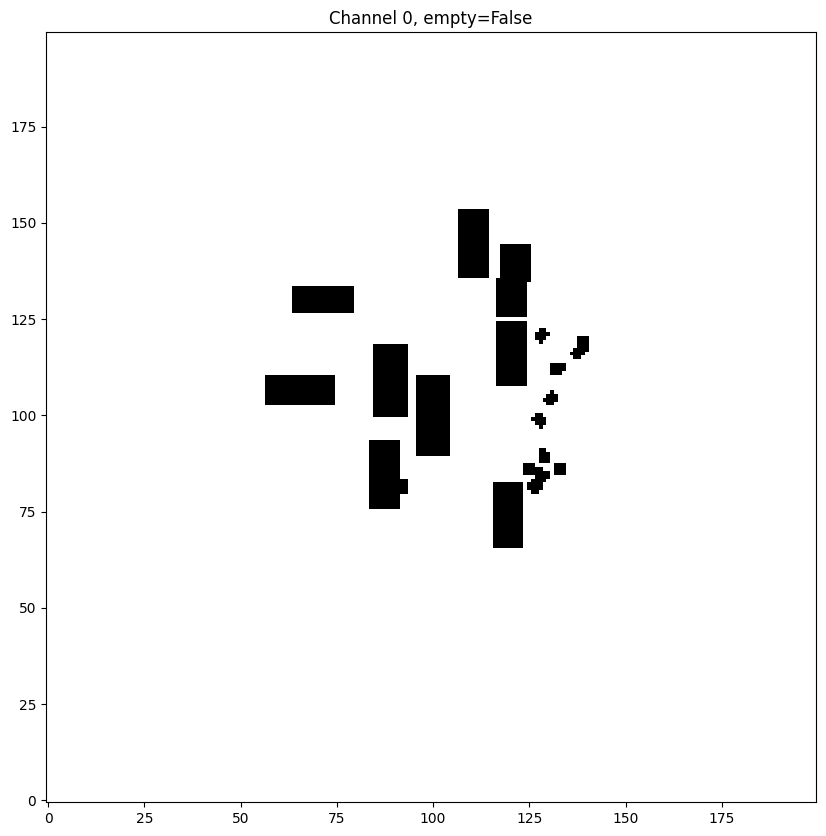

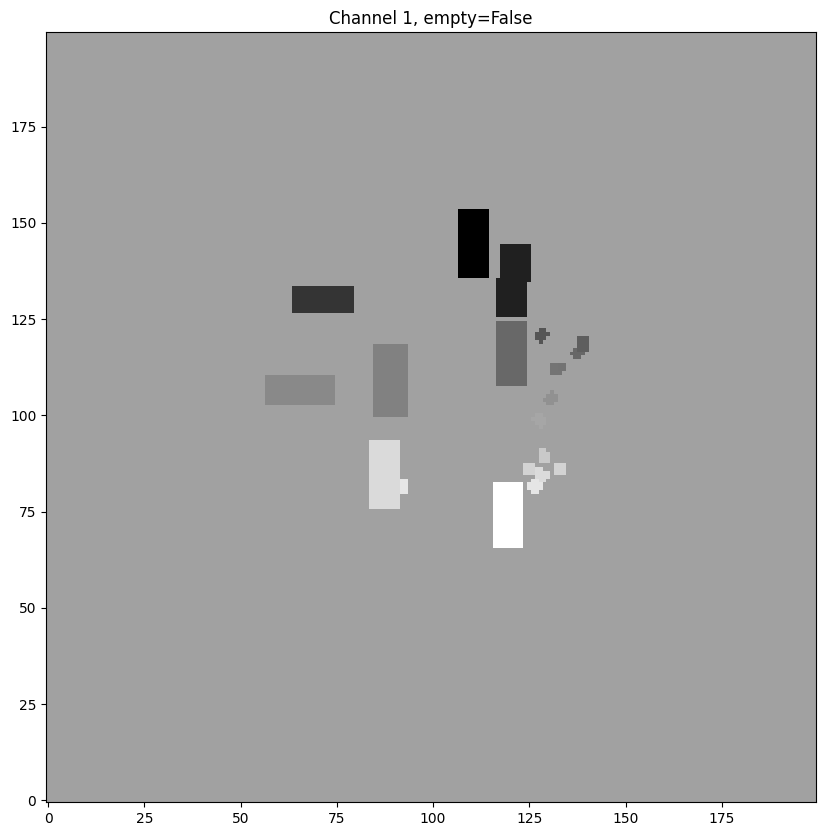

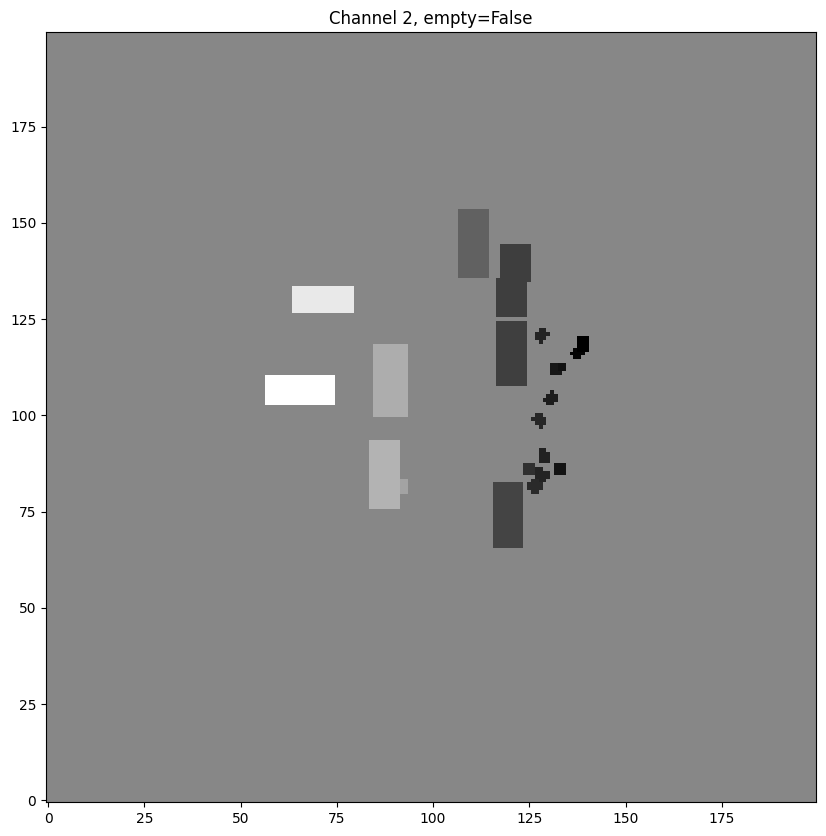

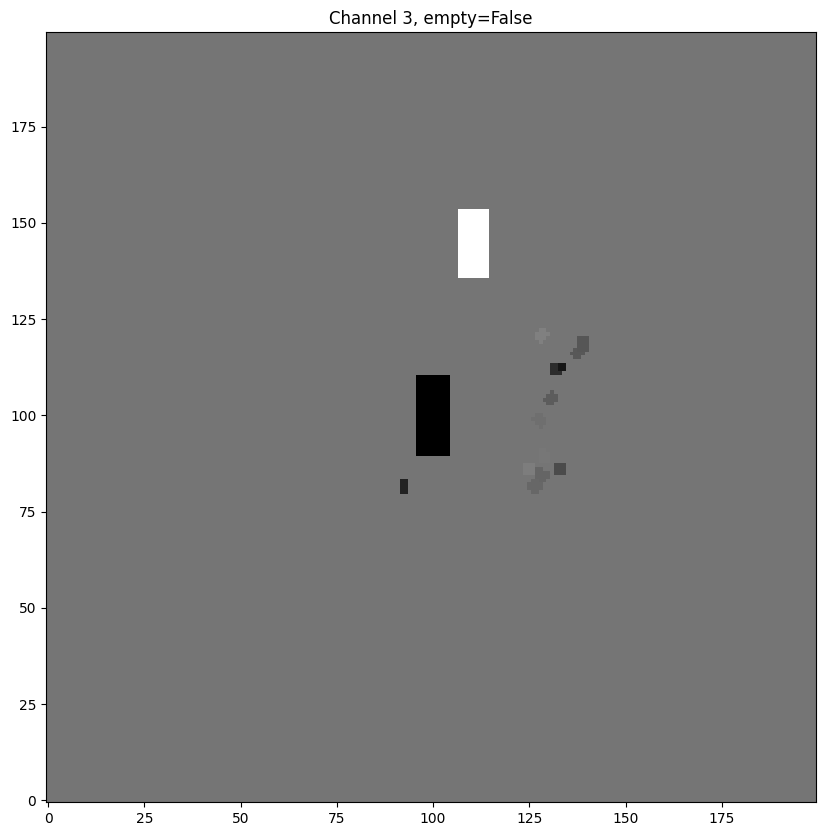

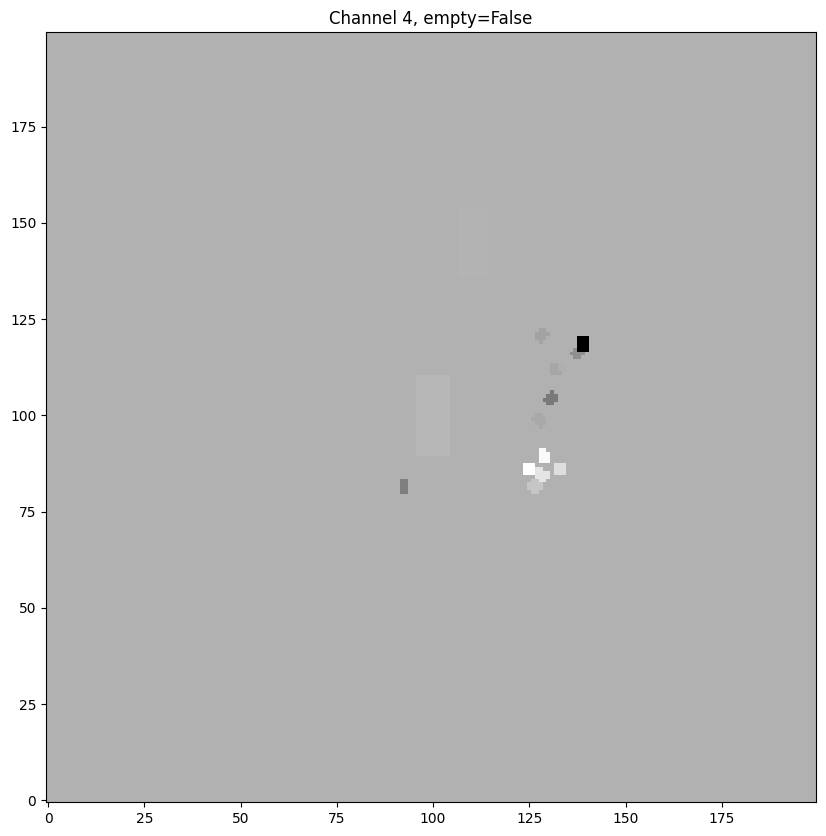

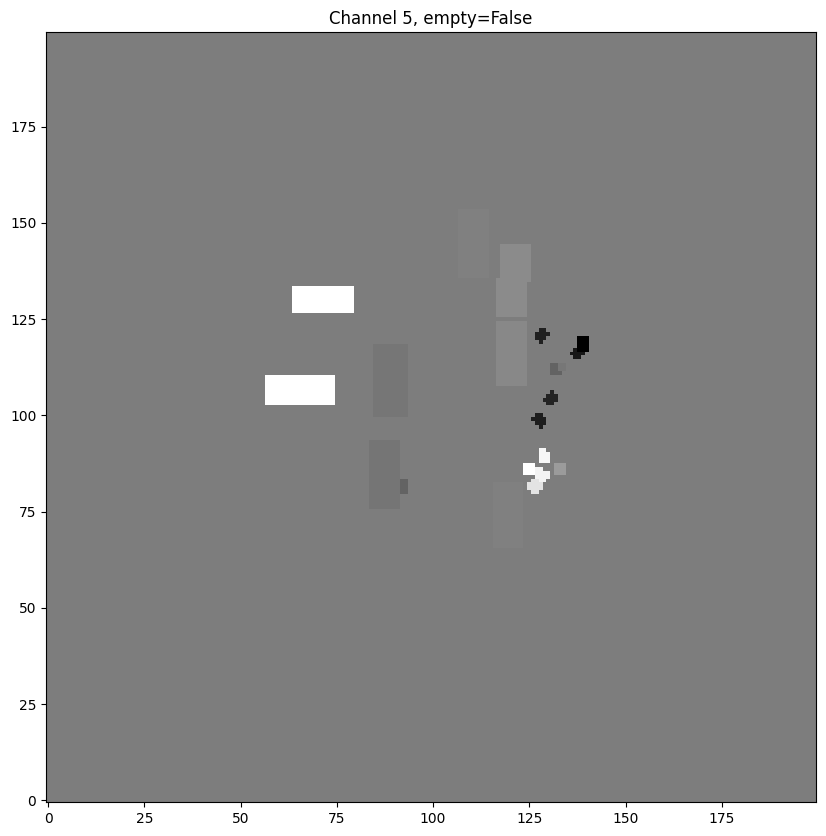

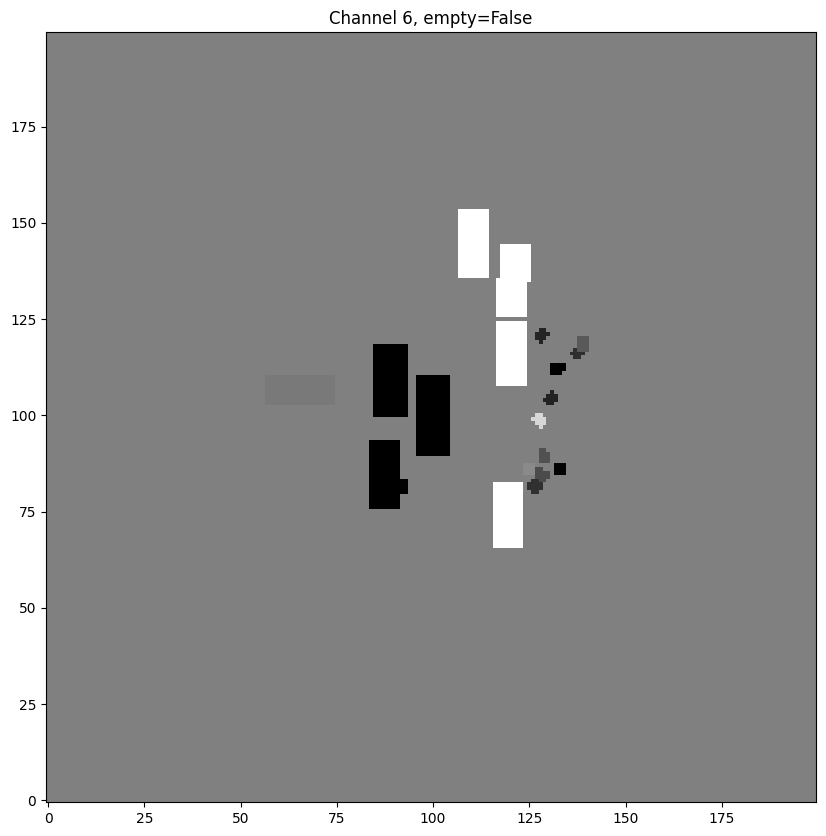

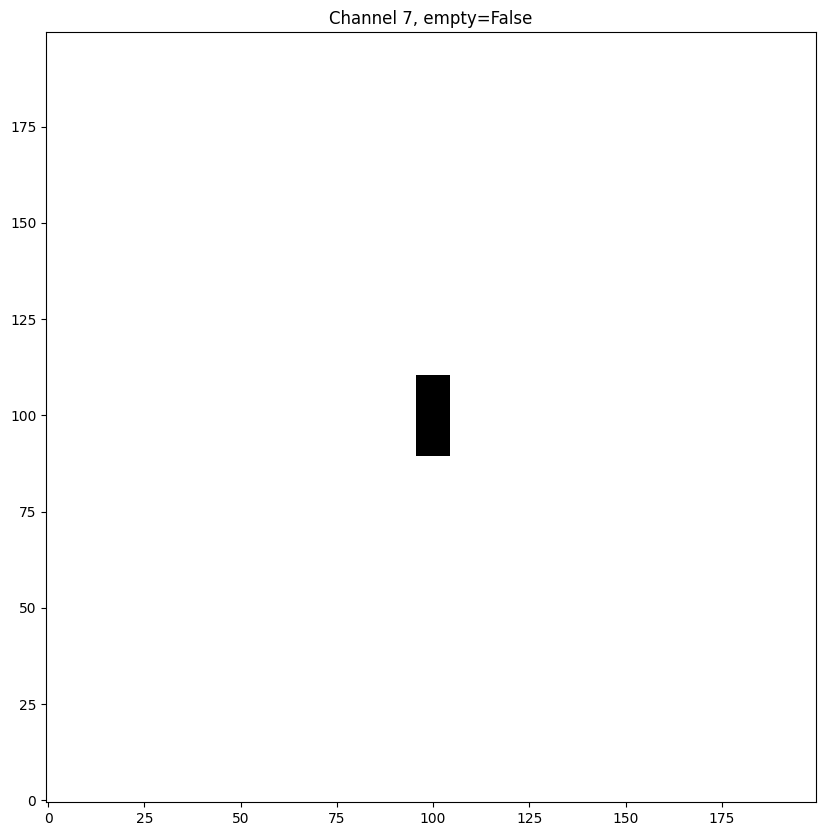

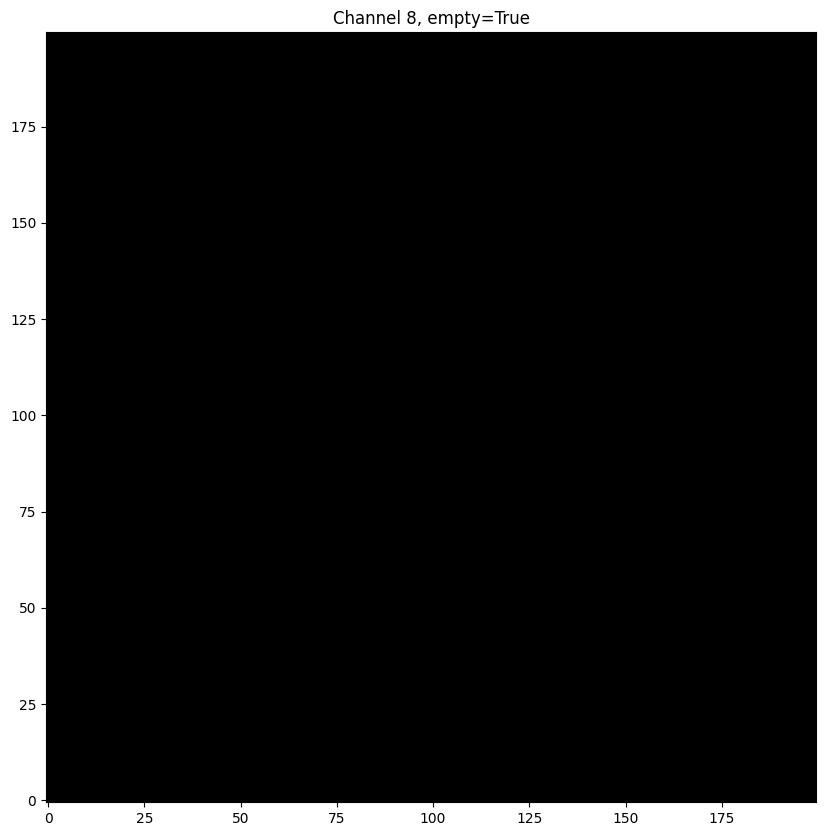

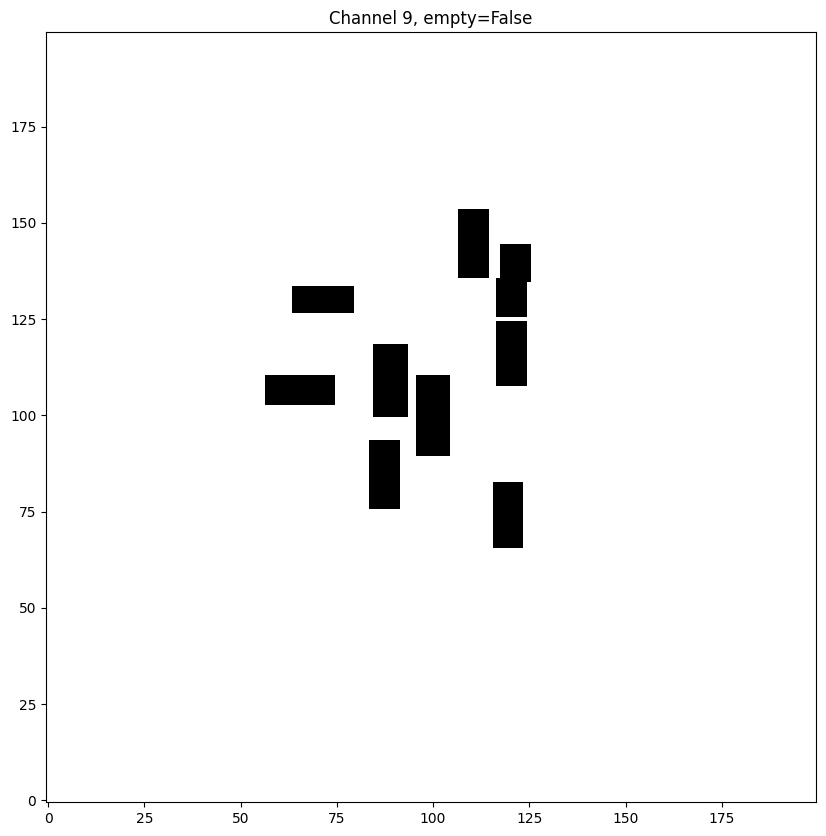

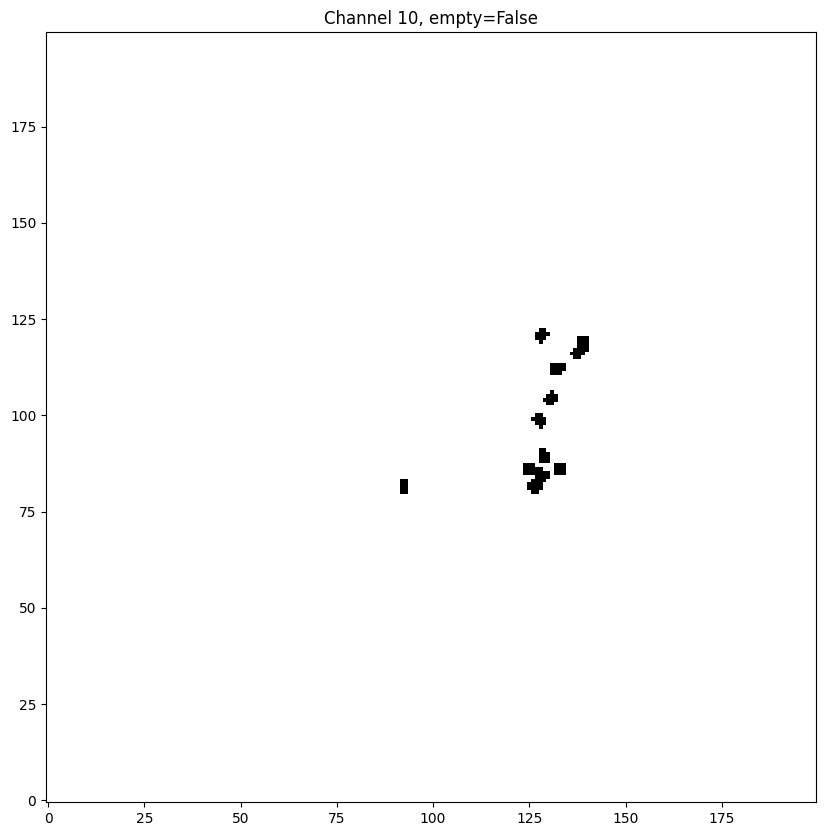

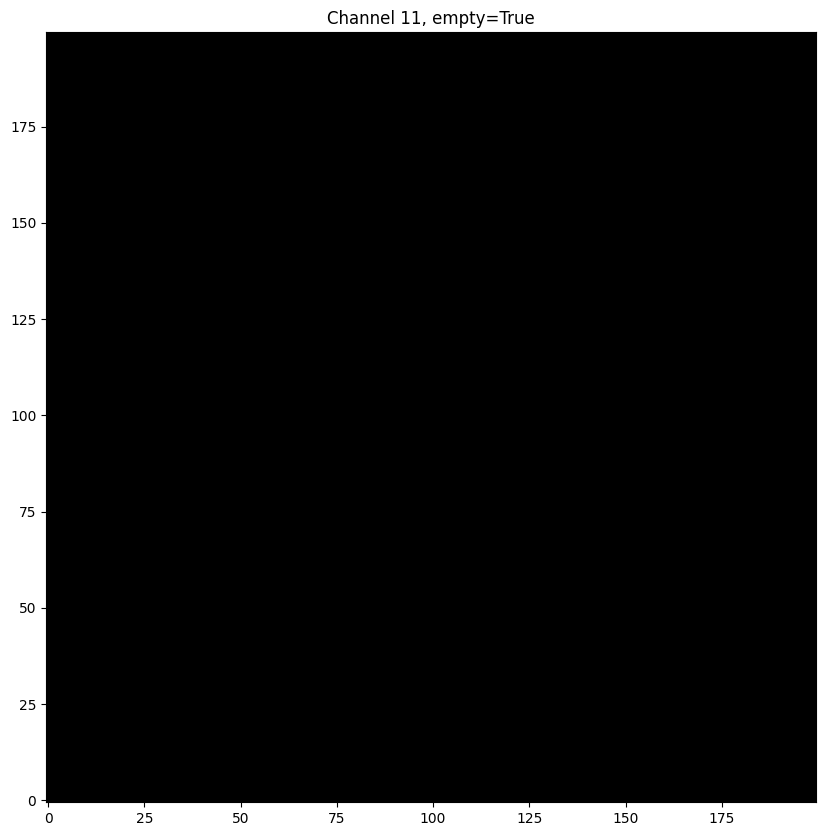

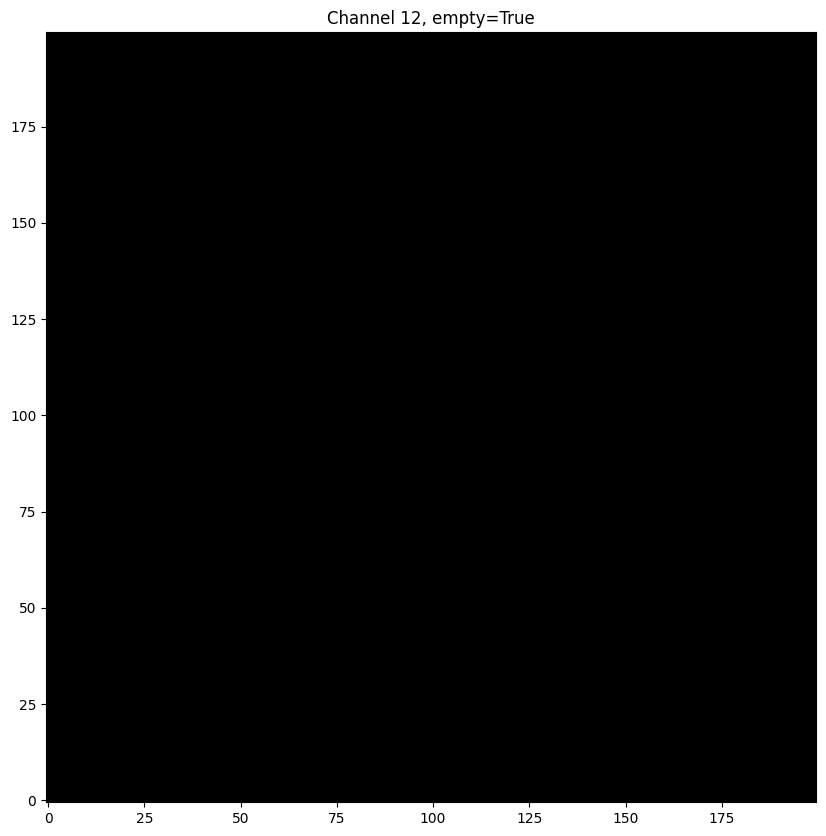

In [143]:
plot_feature_map(agent_map)

Тест на 2 балла

In [144]:
# fails for missing file
# FileNotFoundError: [Errno 2] No such file or directory: '/content/lib/tests/data/agent_map'
# test_agent_renderer(AgentRenderer)

Далее нужно написать рендерер дорожного графа
- На выходе метода `__call__` получиться тензор резмера `[bs, 26, size_x, size_y]`
- Cписок каналов `[1.0, x, y, dir_x, dir_y, type==0, type==1, ..., type==20]`, то есть первый канал константа, а в конце one_hot от тензора `roadgraph_points/types`
- Для каждого элемента карты ставим на фичемапу `state_vector` только в одну координату `(ix, iy)`, cоответствующую `(x, y)` из карты
- Используйте векторные операции без цикла по элементам карты

In [145]:
class RoadGraphRenderer:
    def __init__(
            self,
            size=render_size,
            resolution=0.25):

        self.num_types = 21
        self.channels_size = self.num_types + 5
        self.size = size
        self.resolution = resolution
        self.pixel_transformer = PixelTransformer(size, resolution)

    def __call__(self, features):
        # YOUR CODE HERE
        pt = self.pixel_transformer

        xs = features['roadgraph_points']['x']
        ys = features['roadgraph_points']['y']
        dir_x = features['roadgraph_points']['dir_x']
        dir_y = features['roadgraph_points']['dir_y']
        types = features['roadgraph_points']['types']
        valid = features['roadgraph_points']['valid']  # [bs, ...]

        # Precompute one-hot encodings for all agents
        # type_one_hot = F.one_hot(object_types.long(), num_classes=self.num_types).float()
        type_one_hot = F.one_hot(torch.clamp(types.long(), min=0), num_classes=self.num_types).float().to(device)

        batch_size, num_points = xs.shape
        feature_map = torch.zeros(batch_size, self.channels_size, self.size, self.size, device=device)

        ixs, iys = pt.to_clipped_pixel(xs, ys)
        ixs, iys = ixs.long().to(device), iys.long().to(device)
        for batch_idx in range(batch_size):
            values = torch.cat(
                [
                    torch.stack(
                        [
                            torch.ones(num_points, device=device),
                            xs[batch_idx].to(device),
                            ys[batch_idx].to(device),
                            dir_x[batch_idx].to(device),
                            dir_y[batch_idx].to(device),
                        ],
                        dim=0
                    ).to(device),
                    type_one_hot[batch_idx].T,
                ],
                dim=0
            ).to(device)
            valid_per_batch = valid[batch_idx].bool().to(device)
            feature_map[batch_idx, :, ixs[batch_idx][valid_per_batch], iys[batch_idx][valid_per_batch]] = values[:, valid_per_batch]


        return feature_map


Референсное решение для `RoadGraphRenderer` работает ~100-150мс в колабе, если ваша реализация медленнее, то обучение в следующем пункте замедлится


In [146]:
%%time
roadgraph_map = RoadGraphRenderer(size=render_size, resolution=0.25)(ego_space_features)


CPU times: user 1.54 s, sys: 100 ms, total: 1.64 s
Wall time: 203 ms


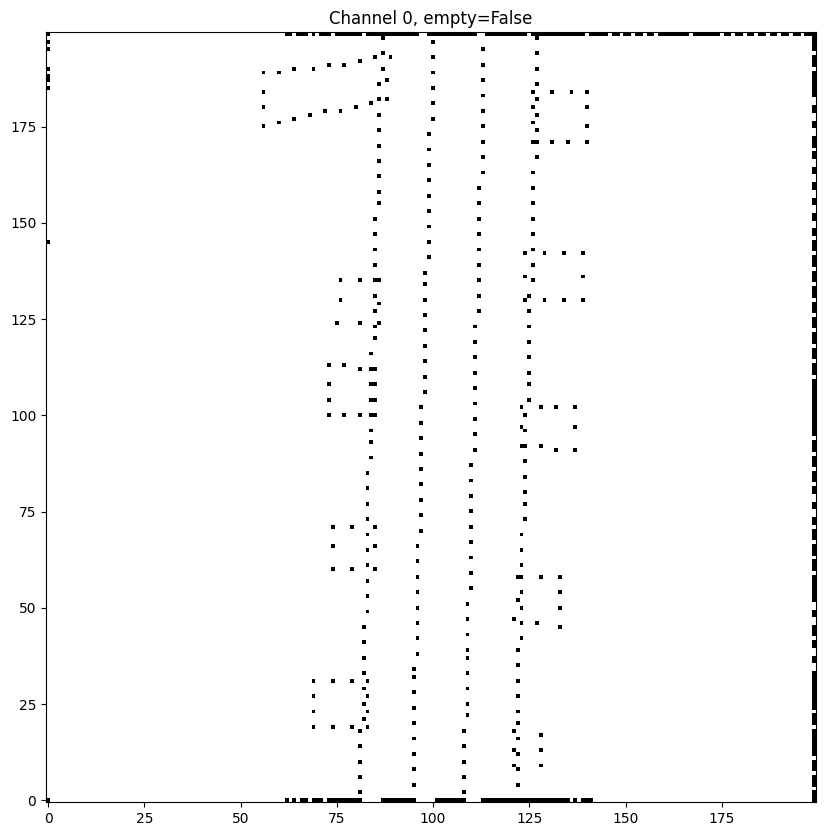

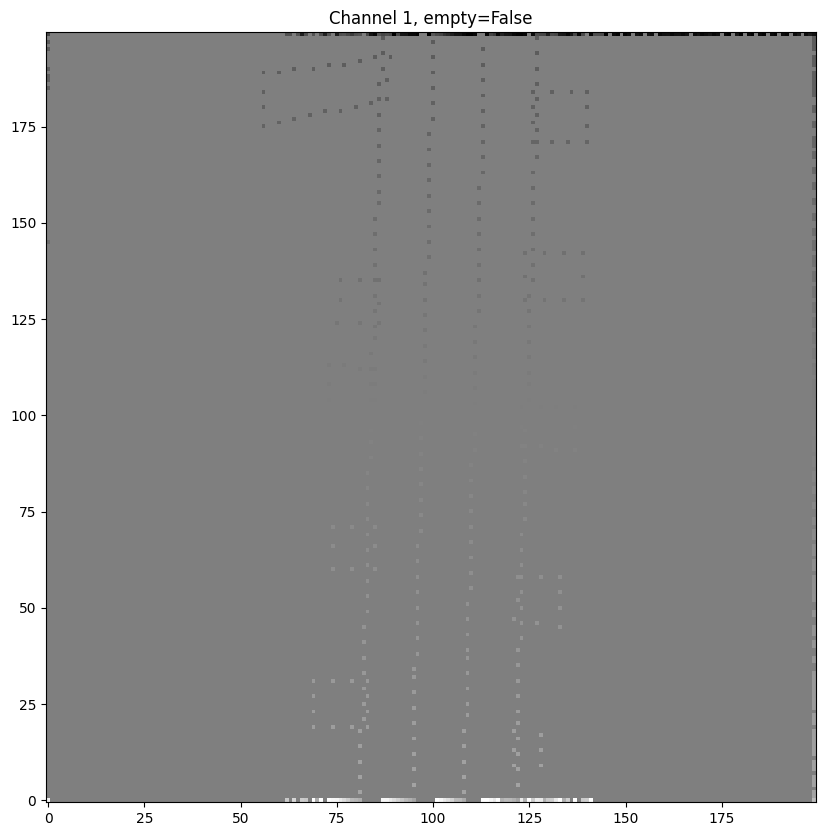

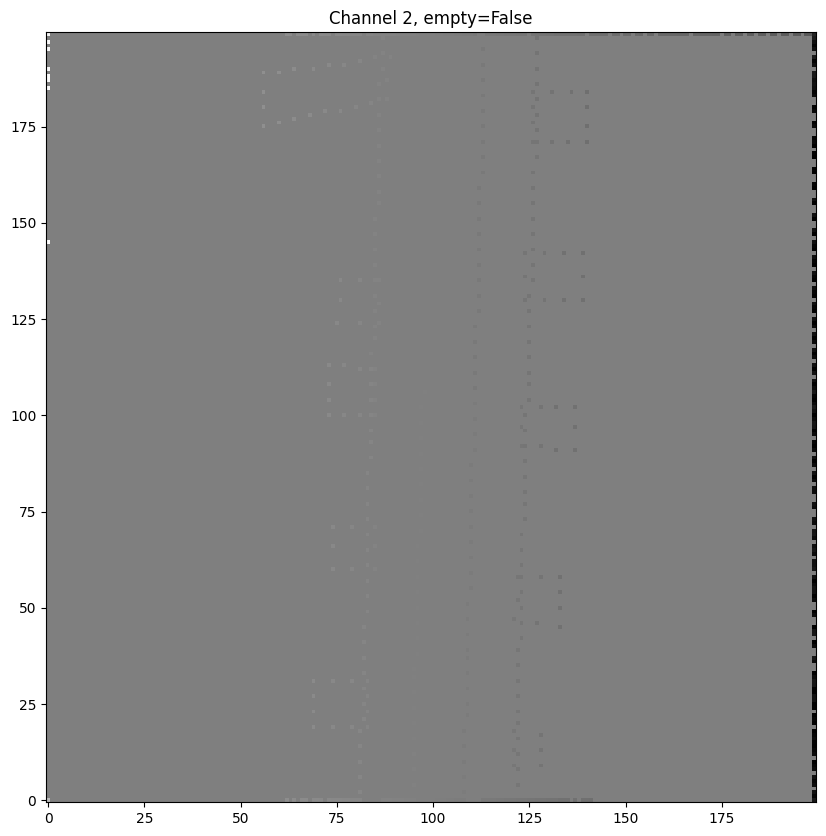

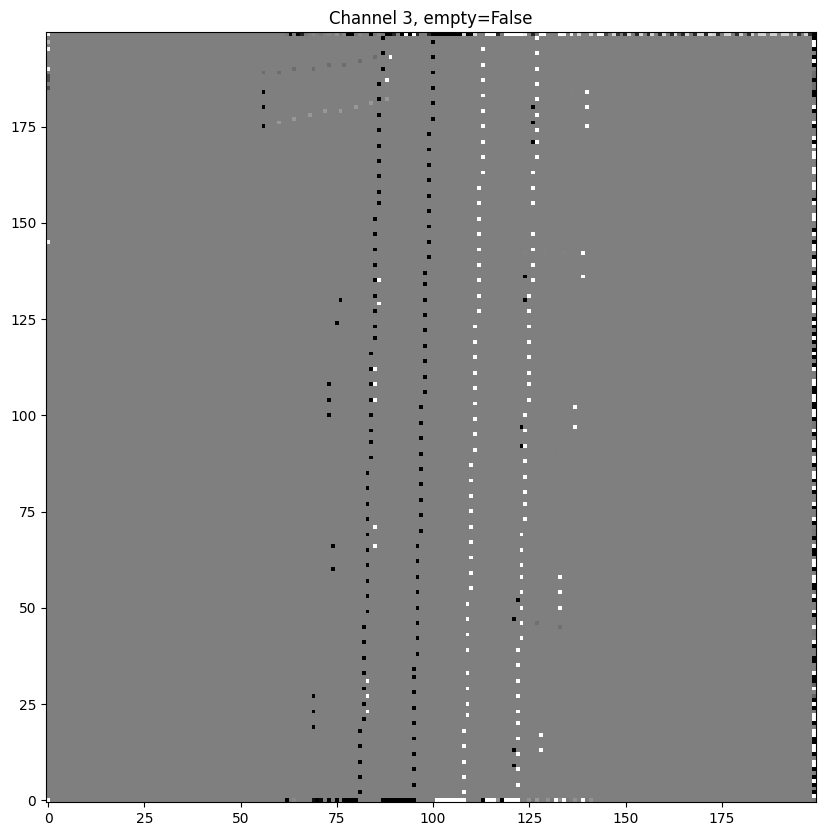

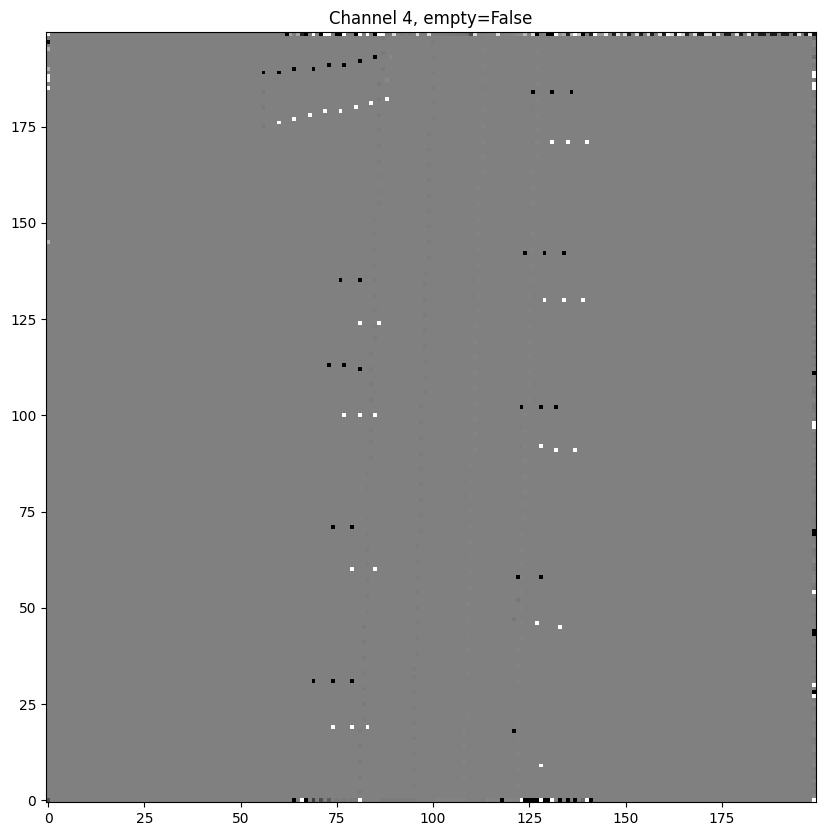

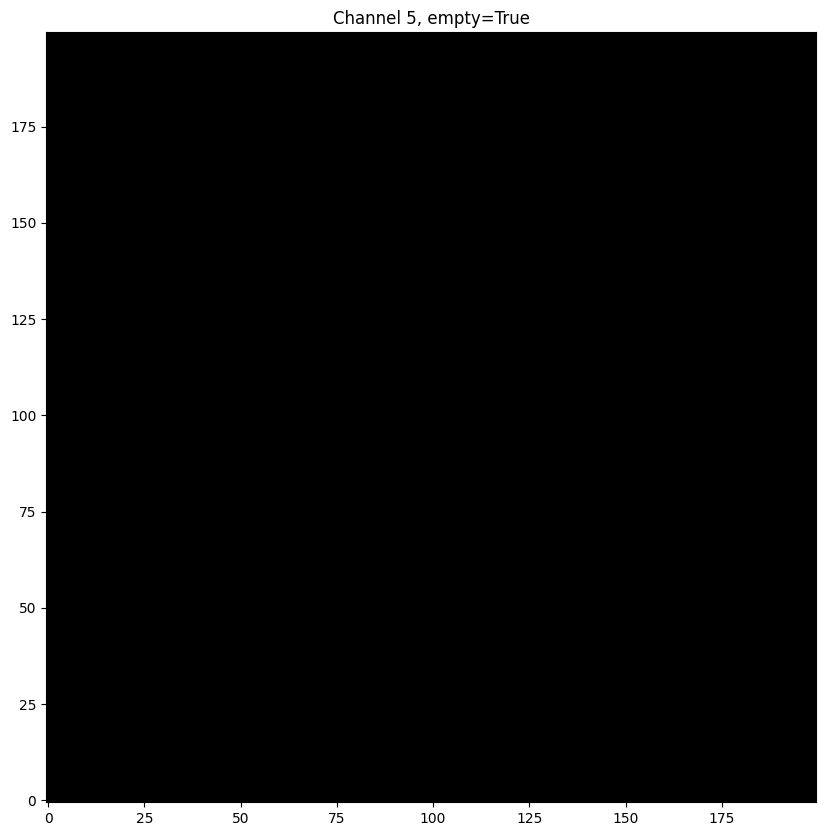

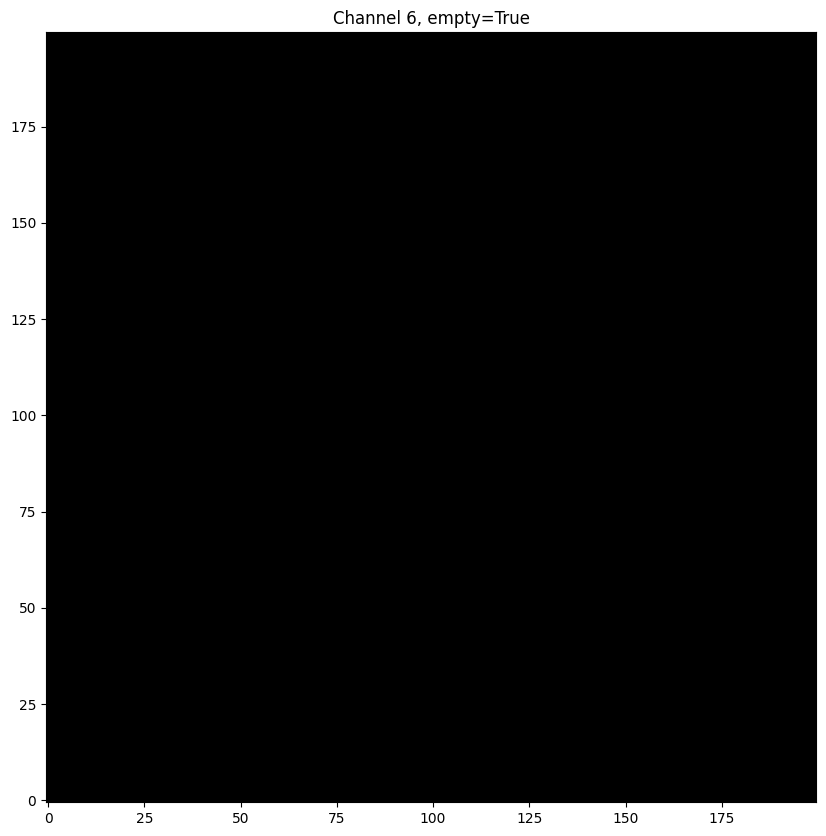

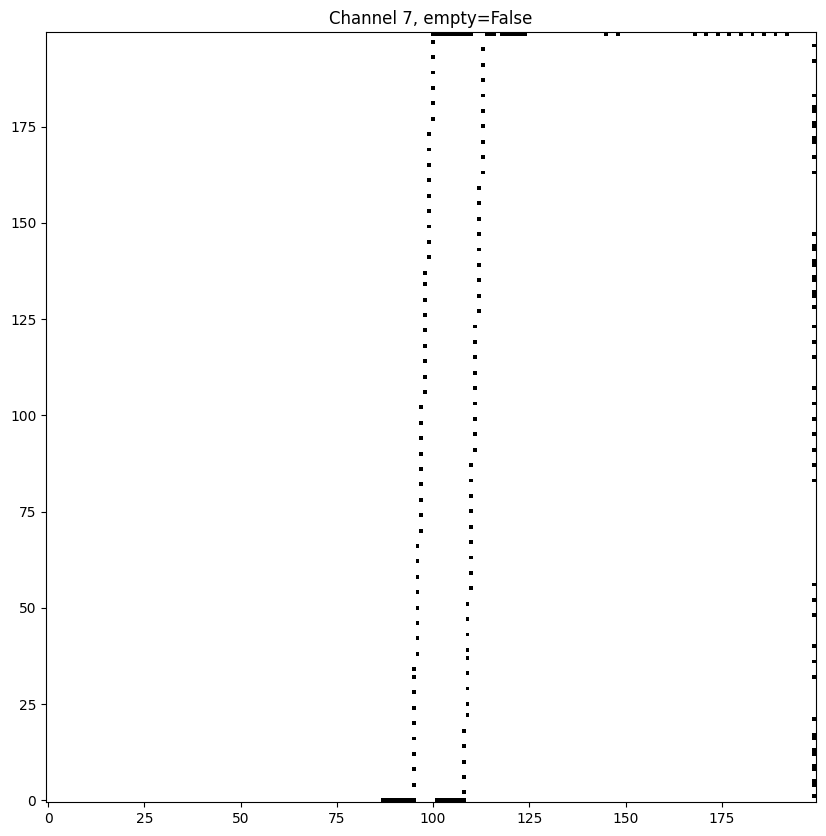

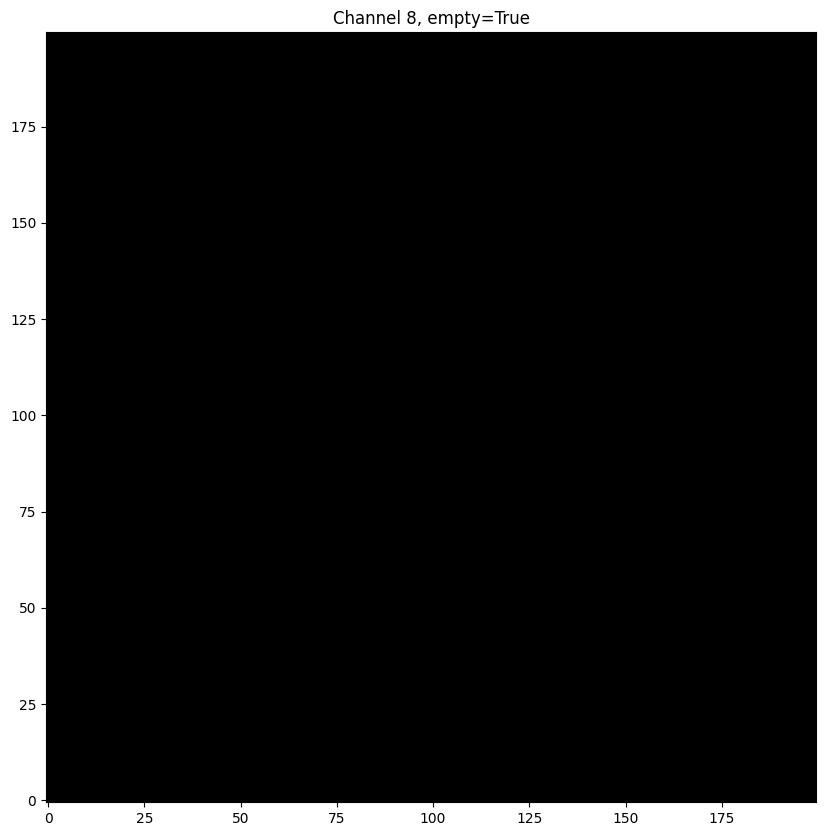

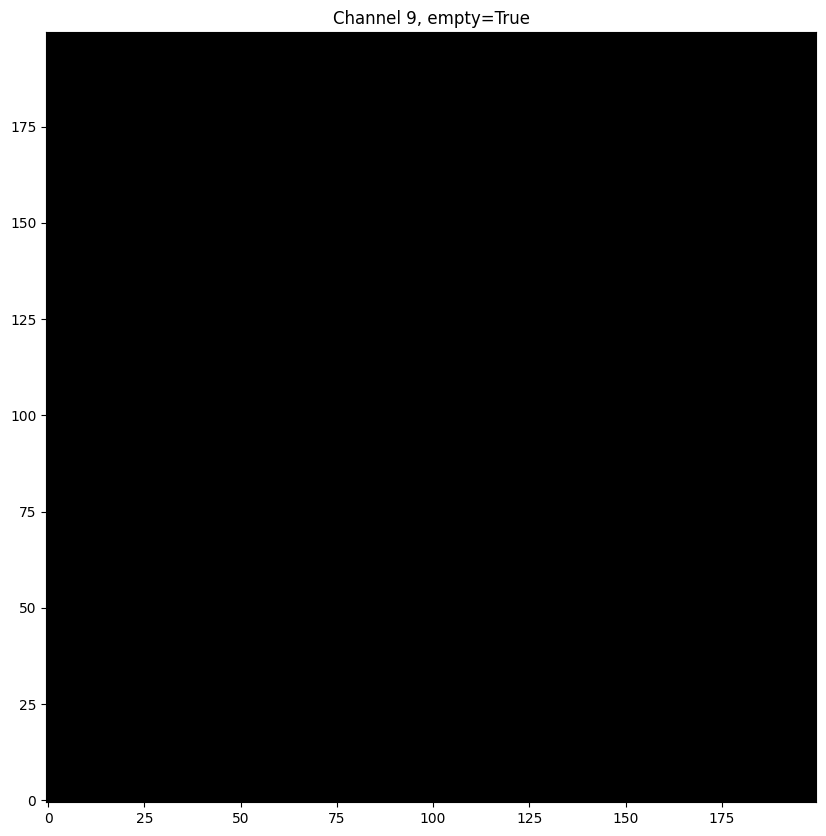

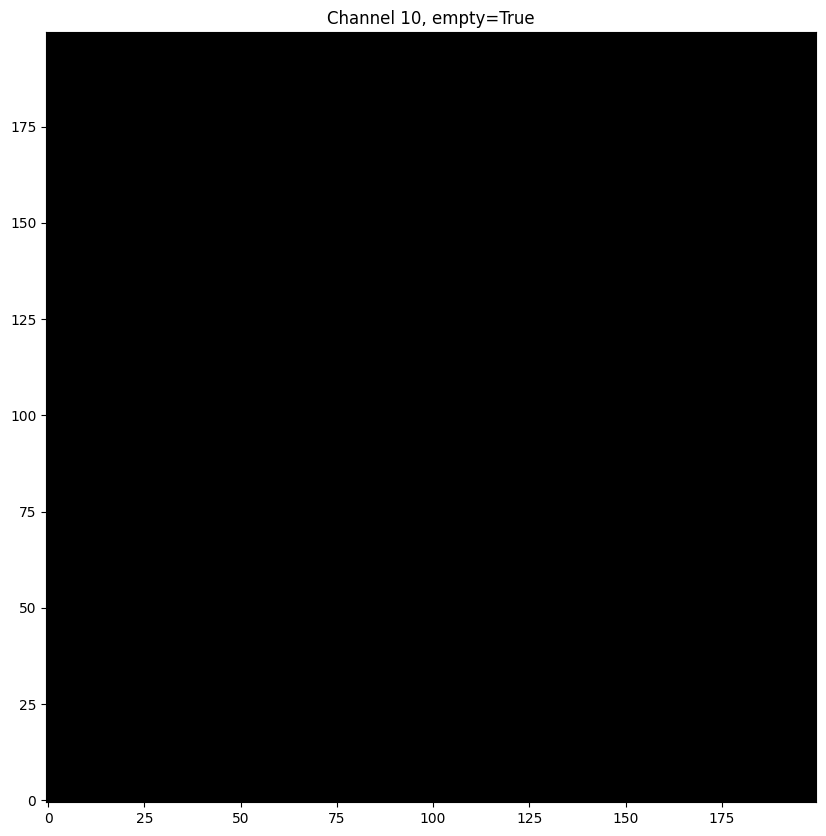

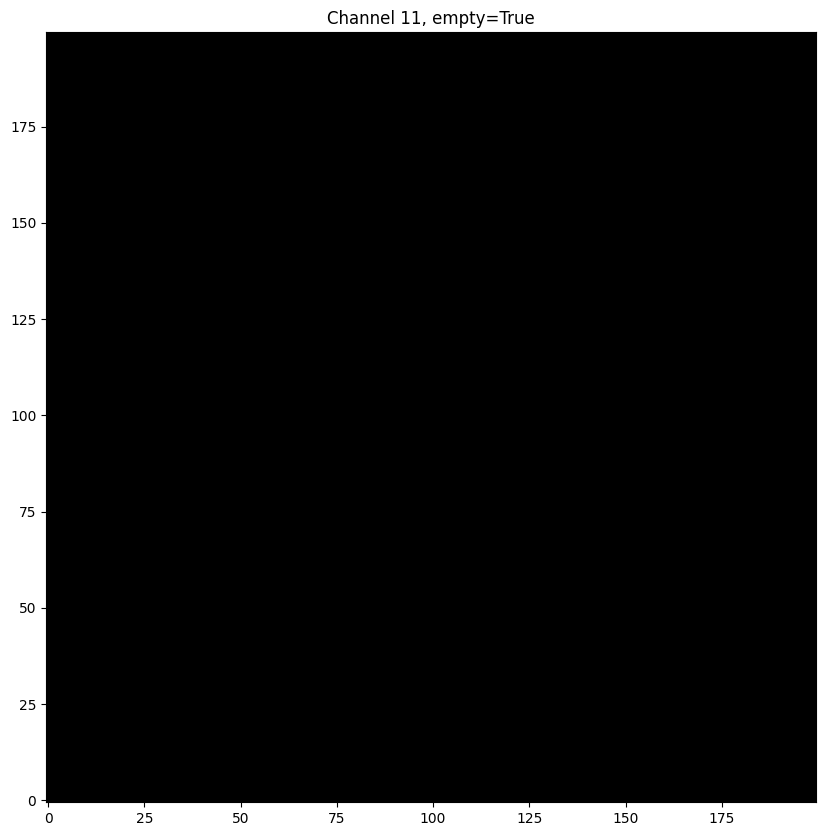

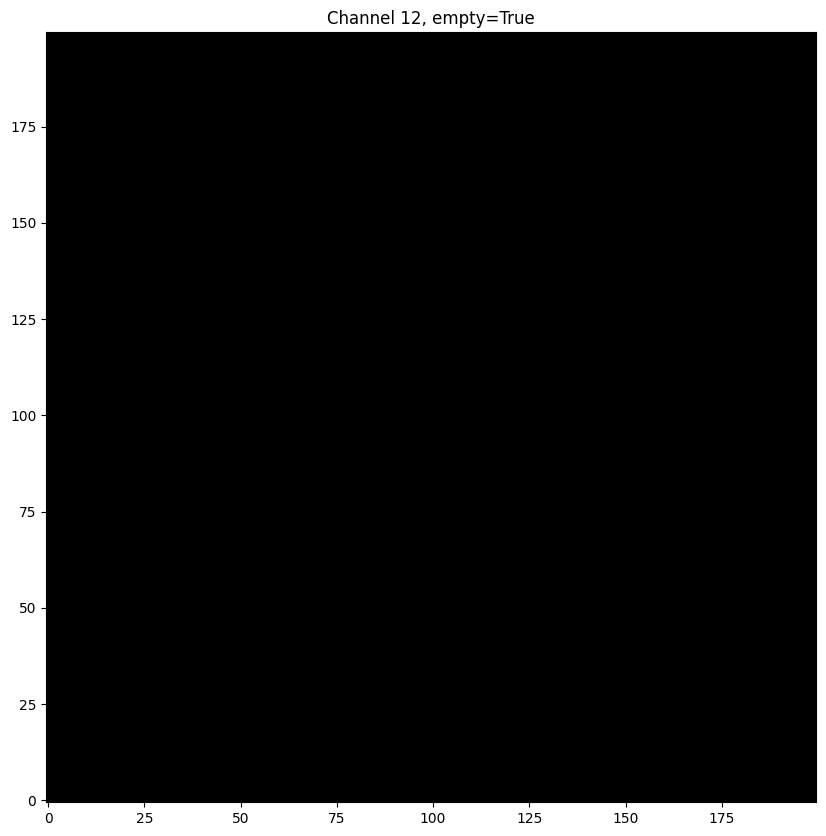

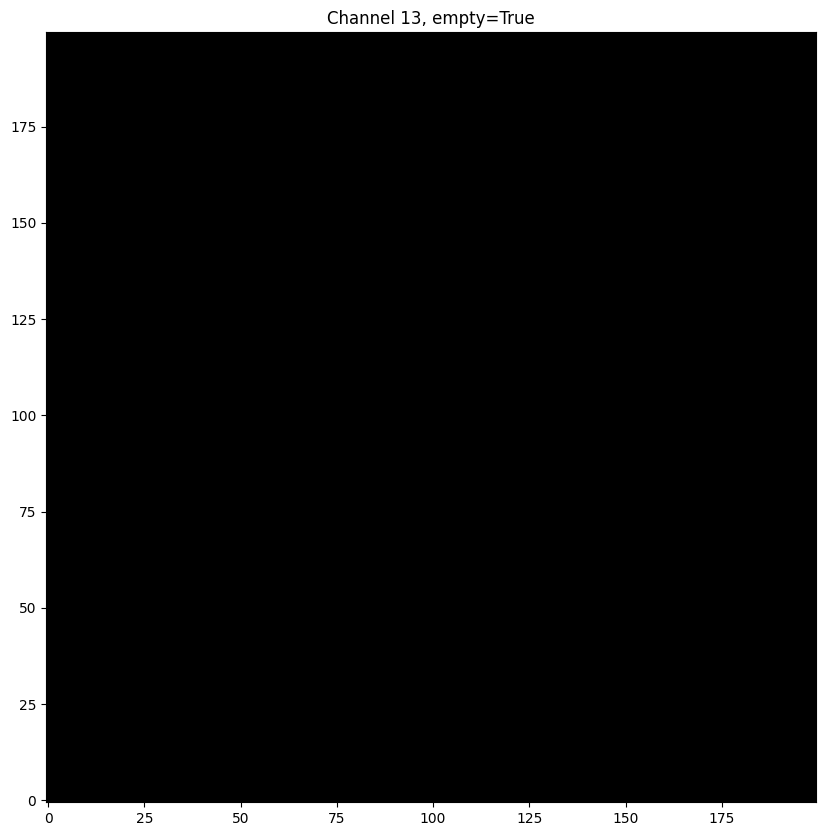

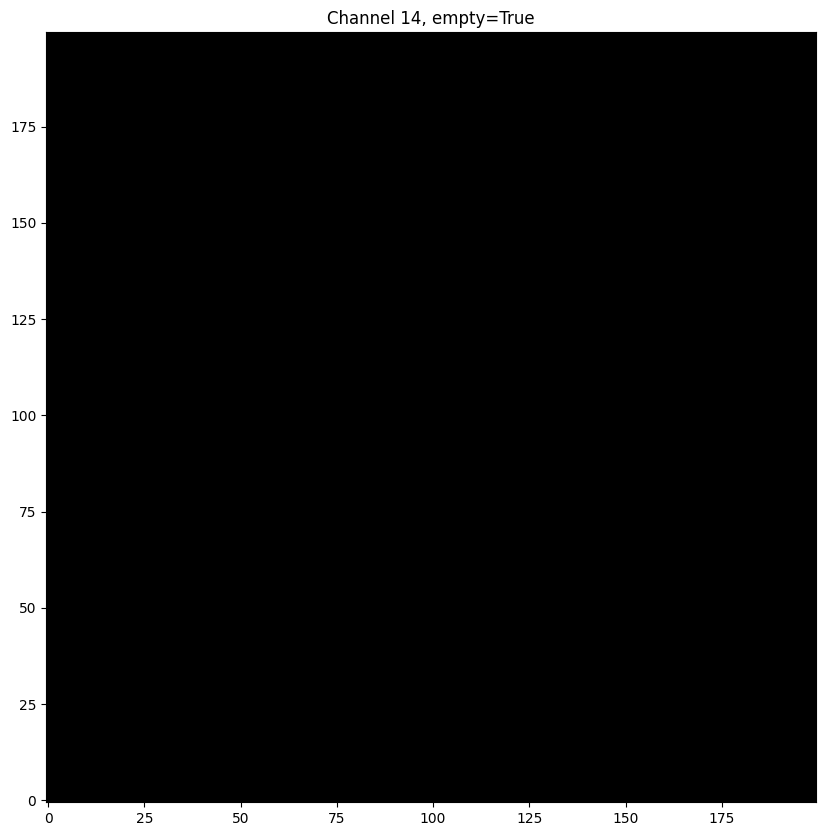

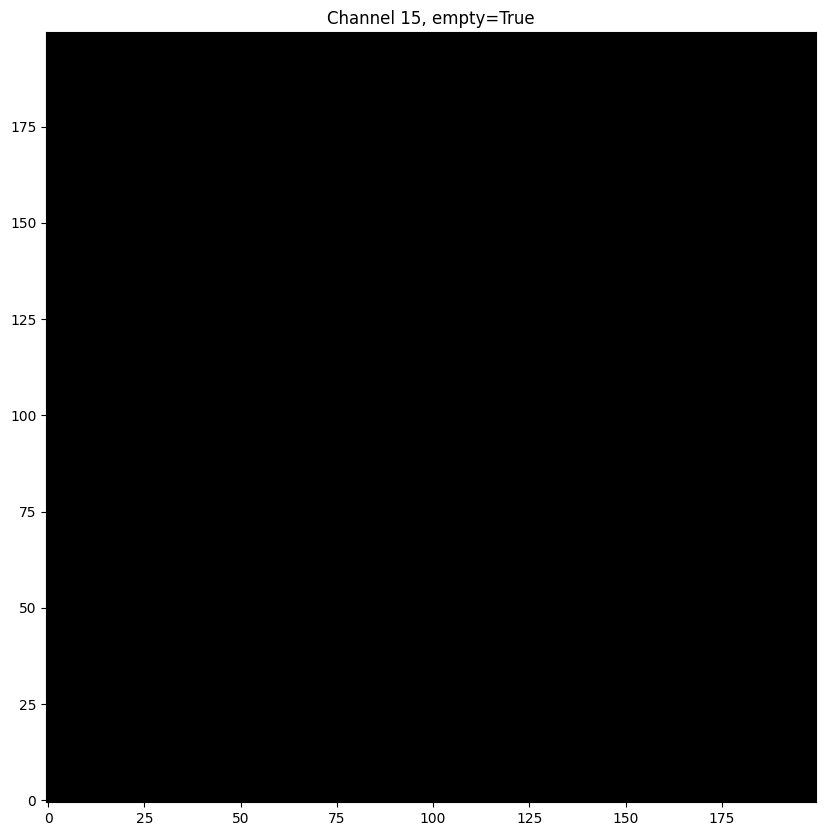

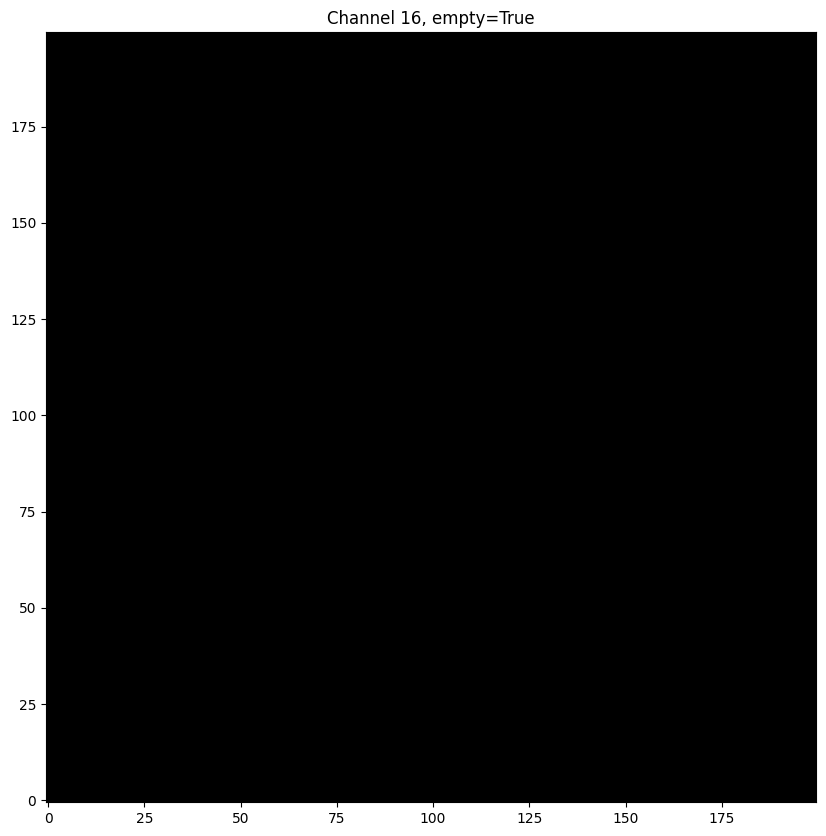

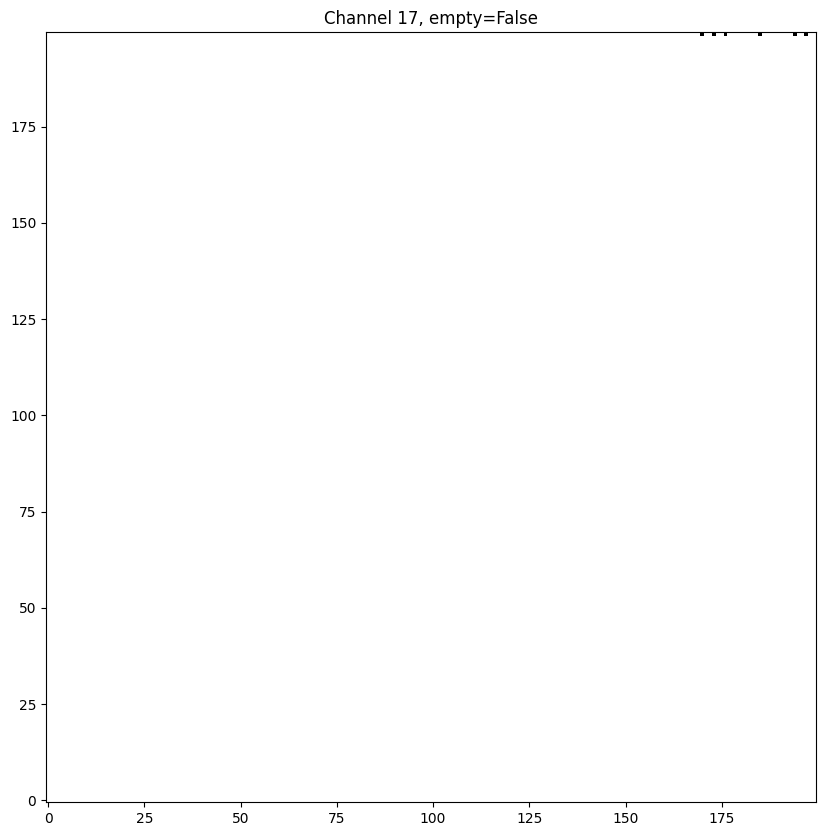

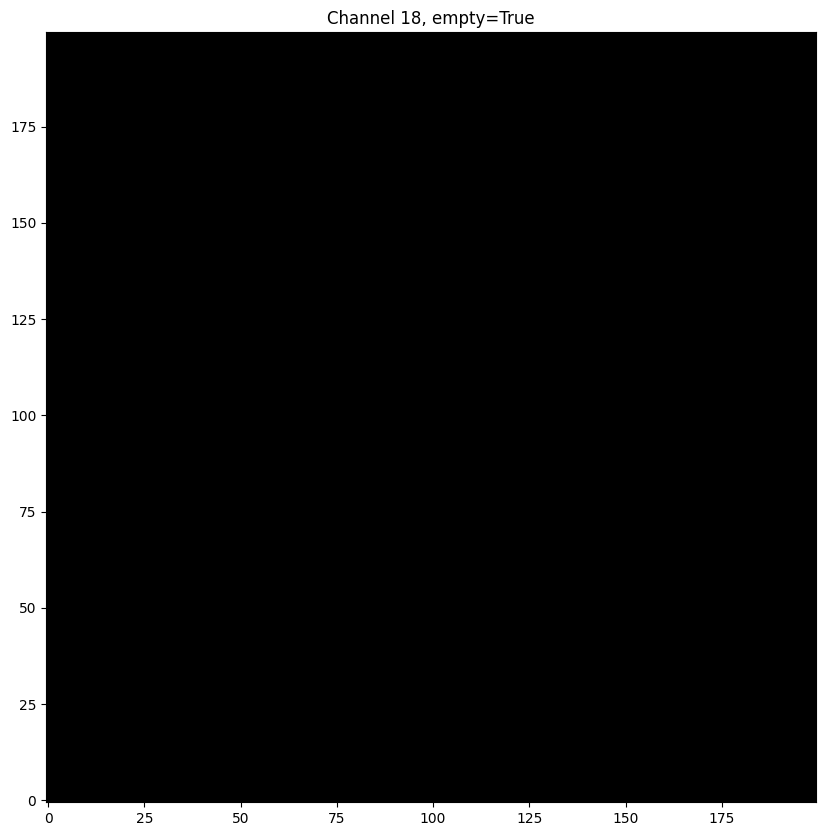

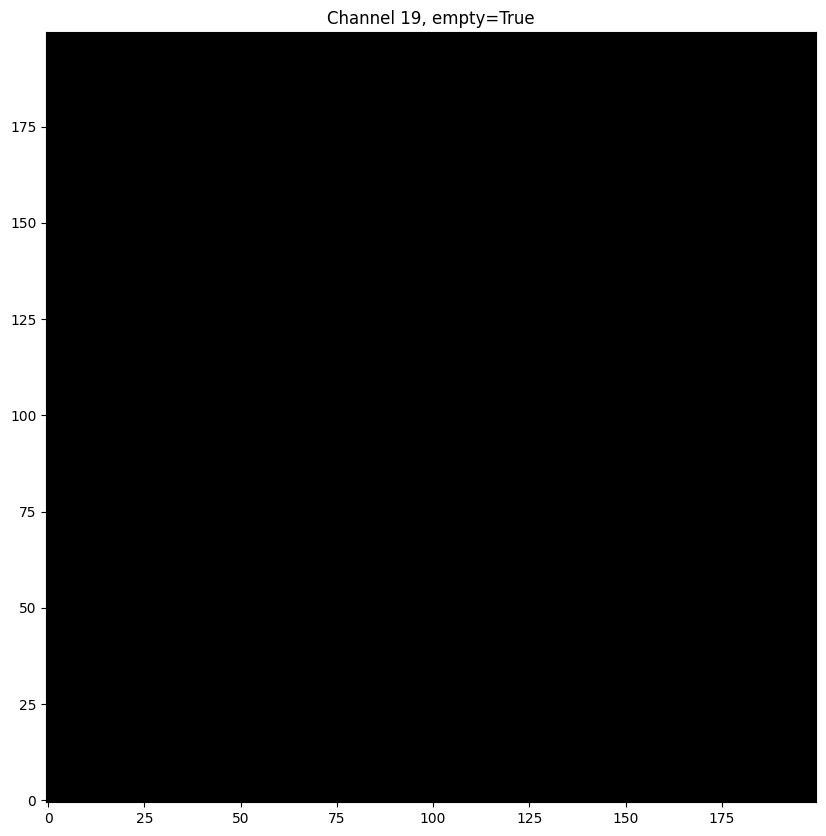

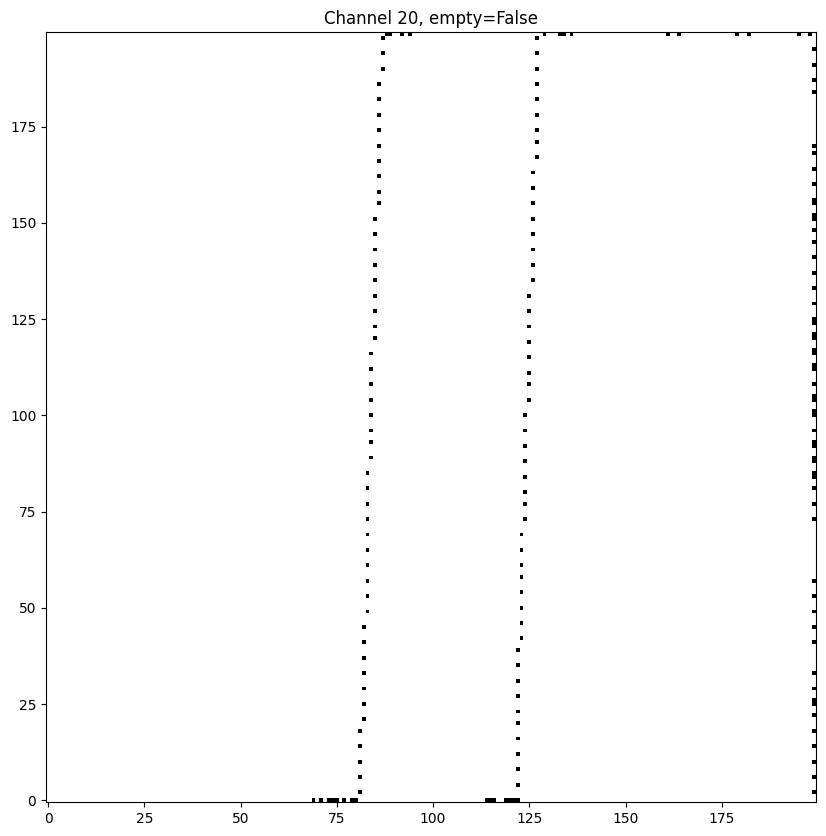

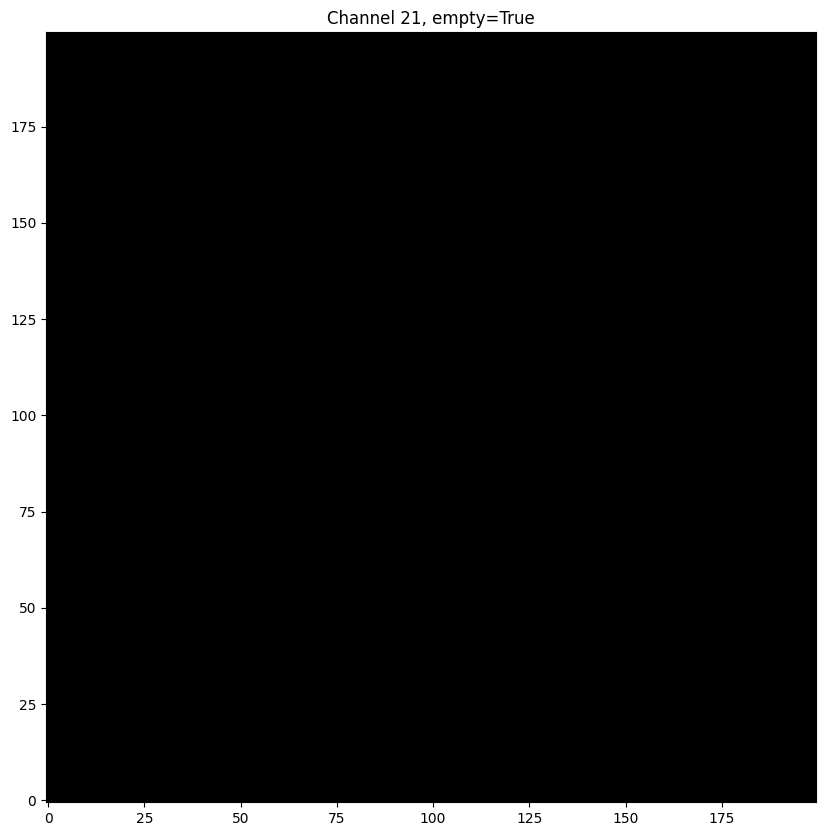

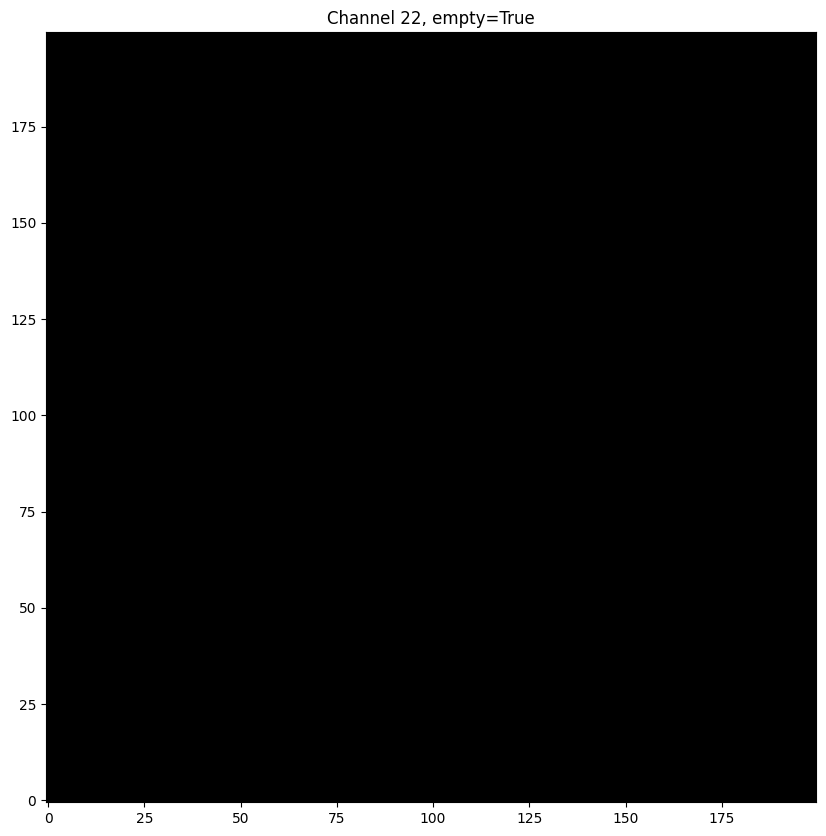

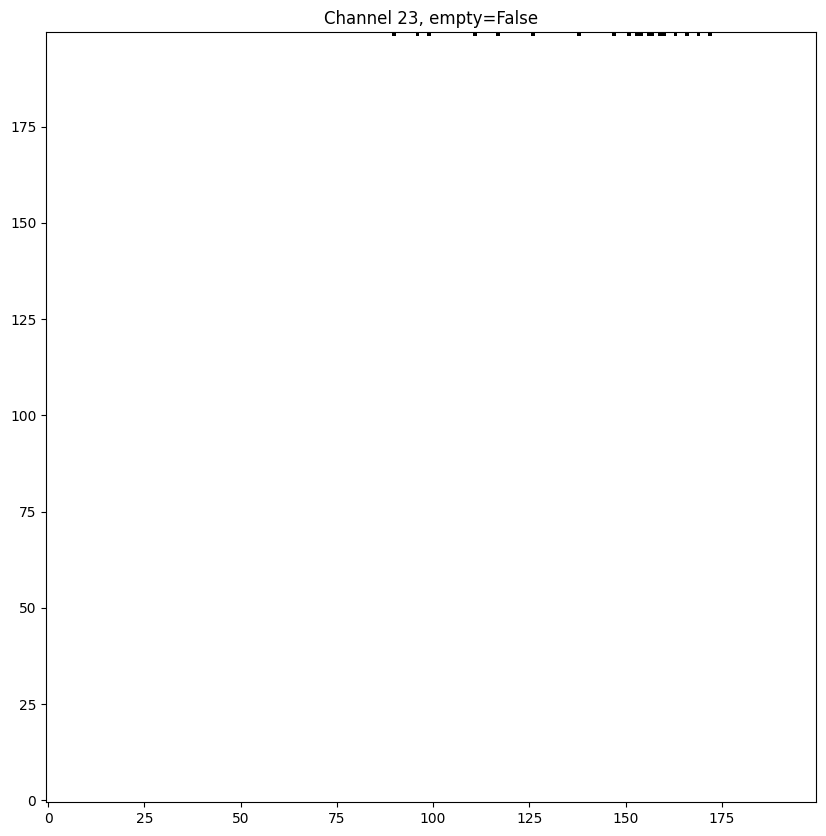

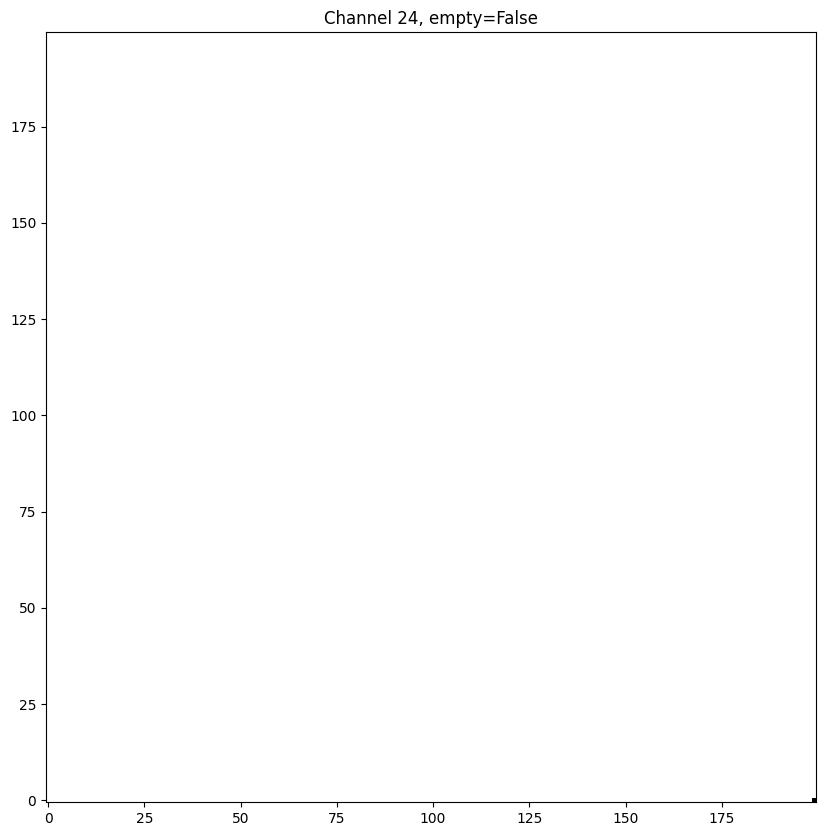

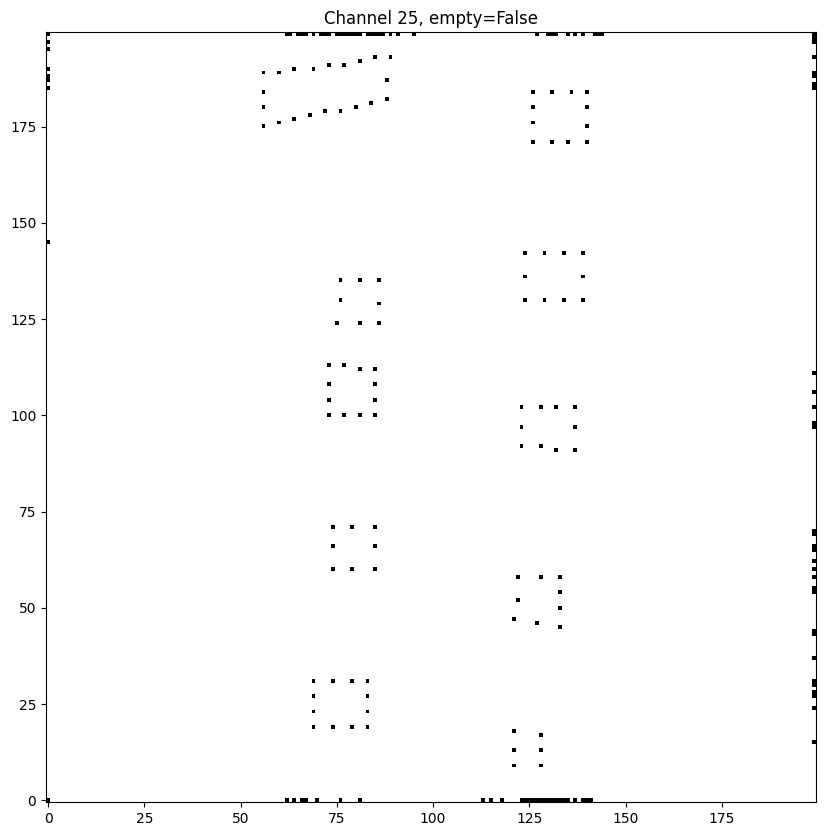

In [147]:
plot_feature_map(roadgraph_map)

Тест на 1 балл




In [148]:
# test fails for missing file
# FileNotFoundError: [Errno 2] No such file or directory: '/content/lib/tests/data/roadgraph_map'
# test_roadgraph_renderer(RoadGraphRenderer)

Далее нужно написать рендерер светофором, аналогично дорожному графу
- На выходе метода `__call__` получиться тензор резмера `[bs, 12, size_x, size_y]`
- Cписок каналов `[1.0, x, y, state==0, state==1, ..., state==8]`, то есть первый канал константа, а в конце one_hot от тензора `log_traffic_light/state`
- Для каждого светофора ставим на фичемапу `state_vector` только в одну координату `(ix, iy)`, cоответствующую `(x, y)` из карты
- `state_vector` содержит состояние в последний тик
- Используйте векторные операции без цикла по элементам карты

In [149]:
features['log_traffic_light'].keys()

dict_keys(['x', 'y', 'z', 'state', 'lane_ids', 'valid'])

In [150]:
class TrafficLightsRenderer:
    def __init__(
            self,
            size=render_size,
            resolution=0.25):

        self.num_states = 9
        self.channels_size = 3 + self.num_states
        self.size = size
        self.resolution = resolution
        self.pixel_transformer = PixelTransformer(size, resolution)

    def __call__(self, features):
        # YOUR CODE HERE
        pt = self.pixel_transformer

        xs = features['log_traffic_light']['x'][..., -1]
        ys = features['log_traffic_light']['y'][..., -1]
        state = features['log_traffic_light']['state'][..., -1]
        valid = features['log_traffic_light']['valid'][..., -1]  # [bs, ...]

        # Precompute one-hot encodings for all agents
        # type_one_hot = F.one_hot(object_types.long(), num_classes=self.num_states).float()
        type_one_hot = F.one_hot(torch.clamp(state.long(), min=0), num_classes=self.num_states).float().to(device)

        batch_size, num_points = xs.shape
        feature_map = torch.zeros(batch_size, self.channels_size, self.size, self.size, device=device)

        ixs, iys = pt.to_clipped_pixel(xs, ys)
        ixs, iys = ixs.long().to(device), iys.long().to(device)
        for batch_idx in range(batch_size):
            values = torch.cat(
                [
                    torch.stack(
                        [
                            torch.ones(num_points, device=device),
                            xs[batch_idx].to(device),
                            ys[batch_idx].to(device),
                        ],
                        dim=0
                    ).to(device),
                    type_one_hot[batch_idx].T,
                ],
                dim=0
            ).to(device)
            valid_per_batch = valid[batch_idx].bool().to(device)
            feature_map[batch_idx, :, ixs[batch_idx][valid_per_batch], iys[batch_idx][valid_per_batch]] = values[:, valid_per_batch]


        return feature_map


Референсное решение для `TrafficLightsRenderer` работает ~40-60мс в колабе, если ваша реализация медленнее, то обучение в следующем пункте замедлится

In [151]:
%%time
trl_map = TrafficLightsRenderer(size=render_size, resolution=0.25)(ego_space_features)


CPU times: user 29.8 ms, sys: 5.34 ms, total: 35.2 ms
Wall time: 22.3 ms


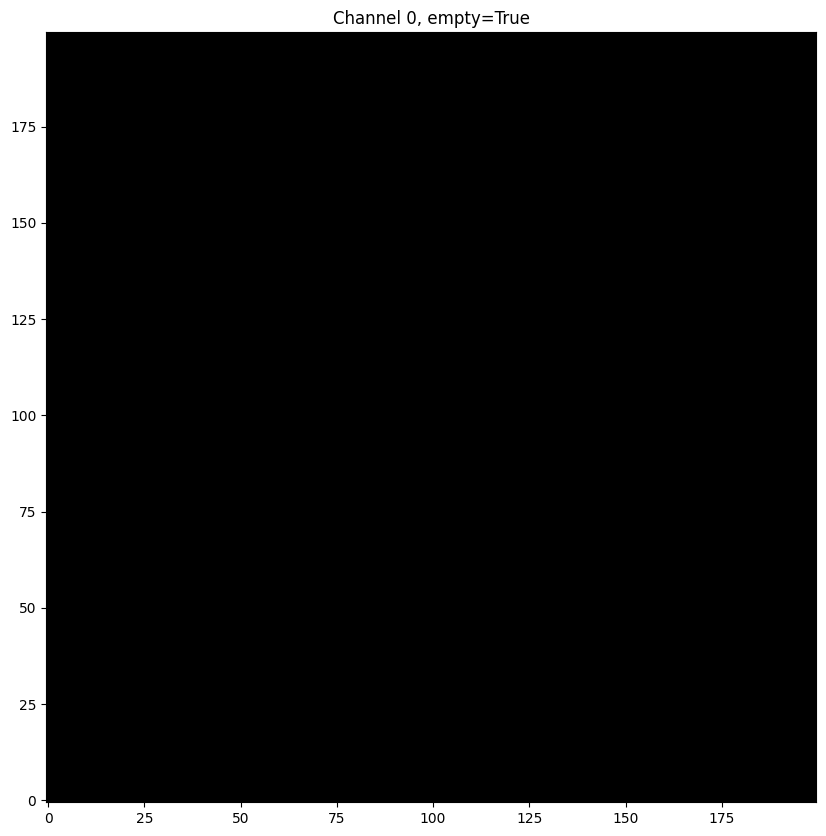

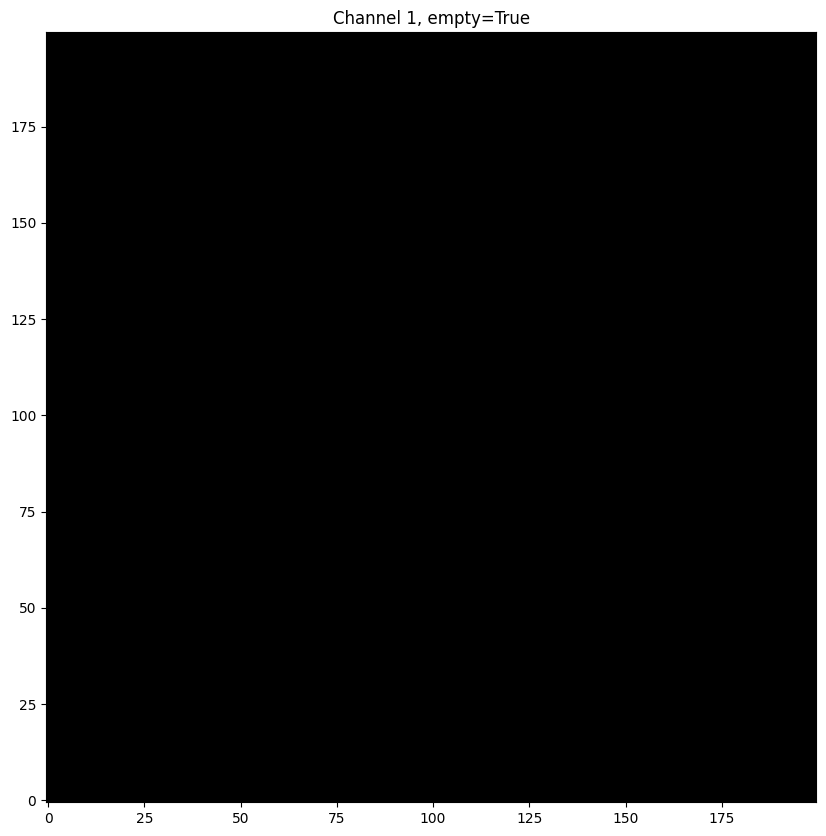

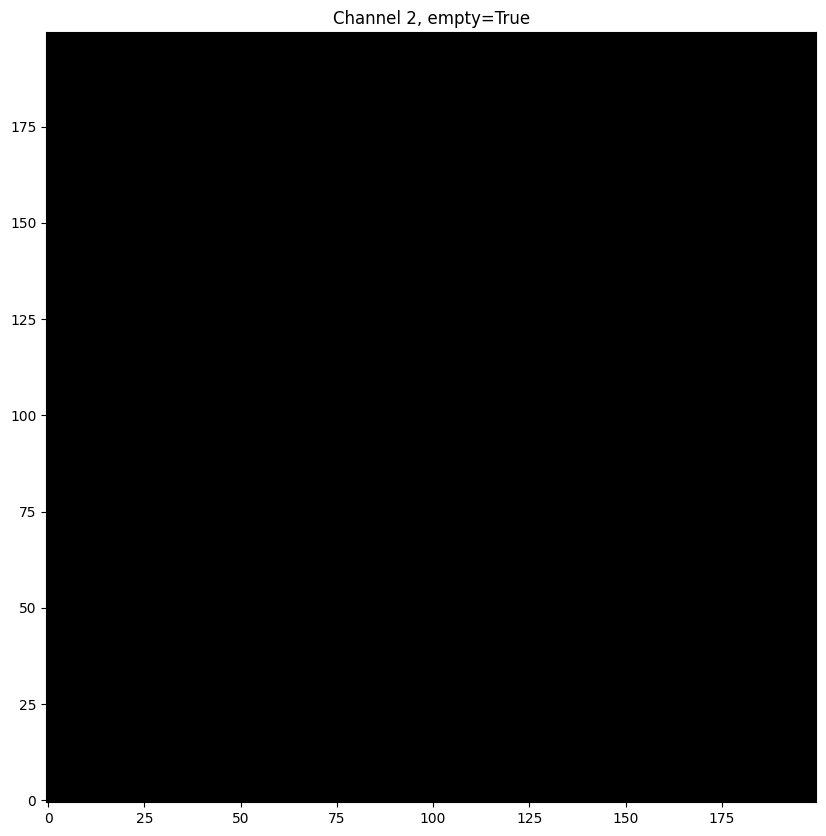

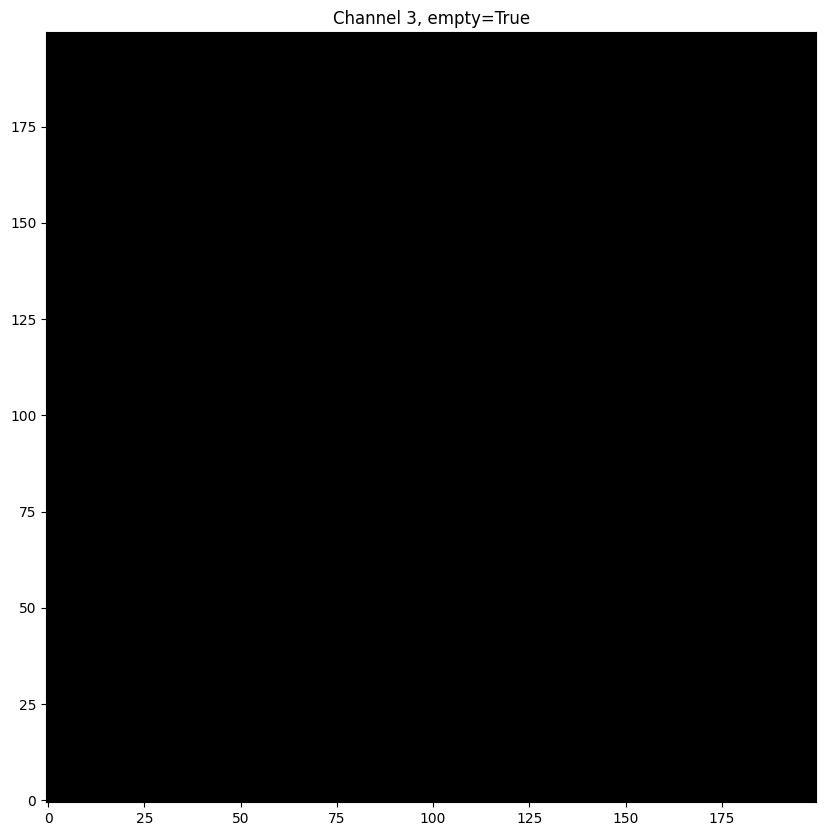

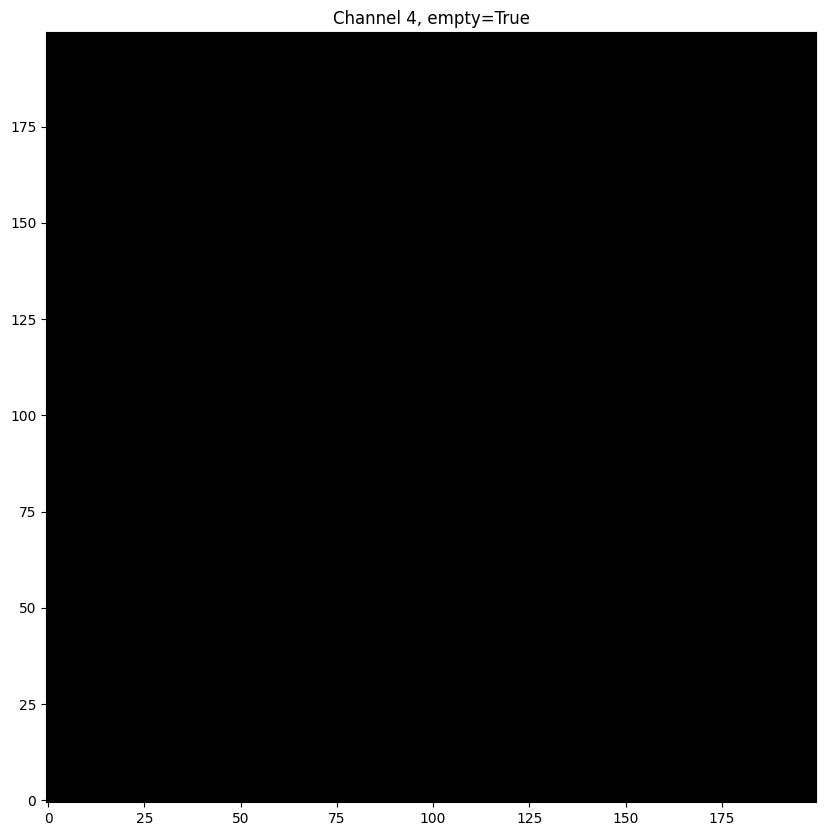

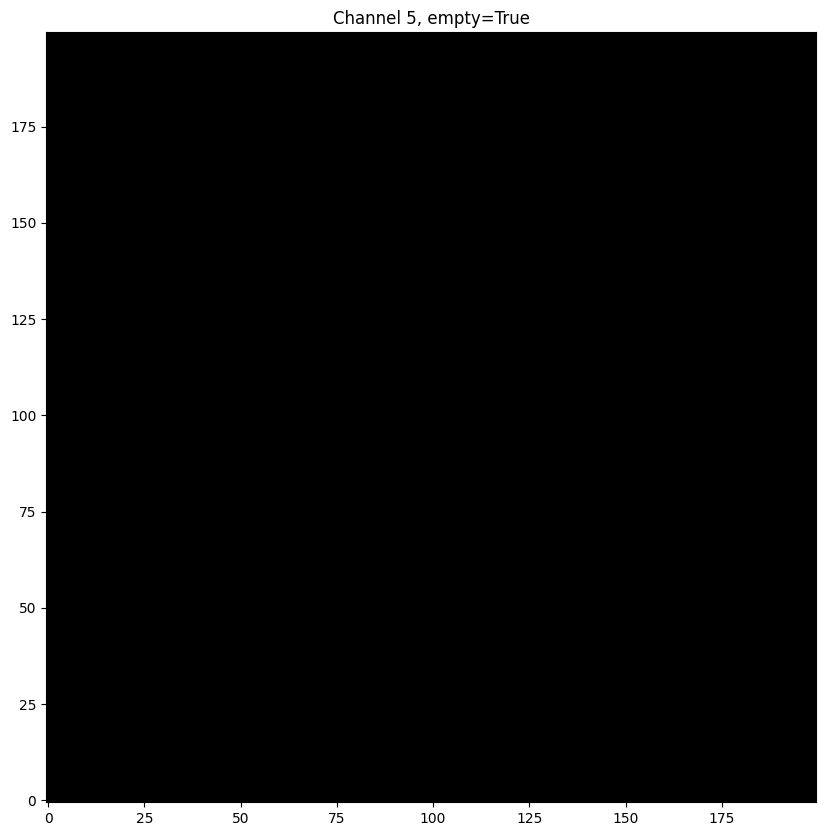

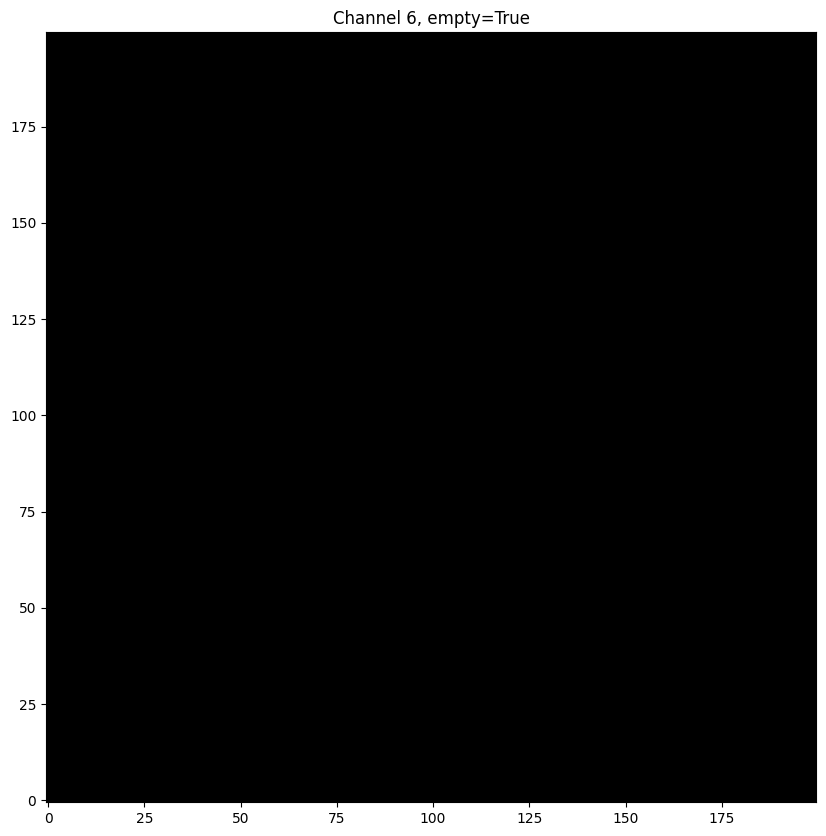

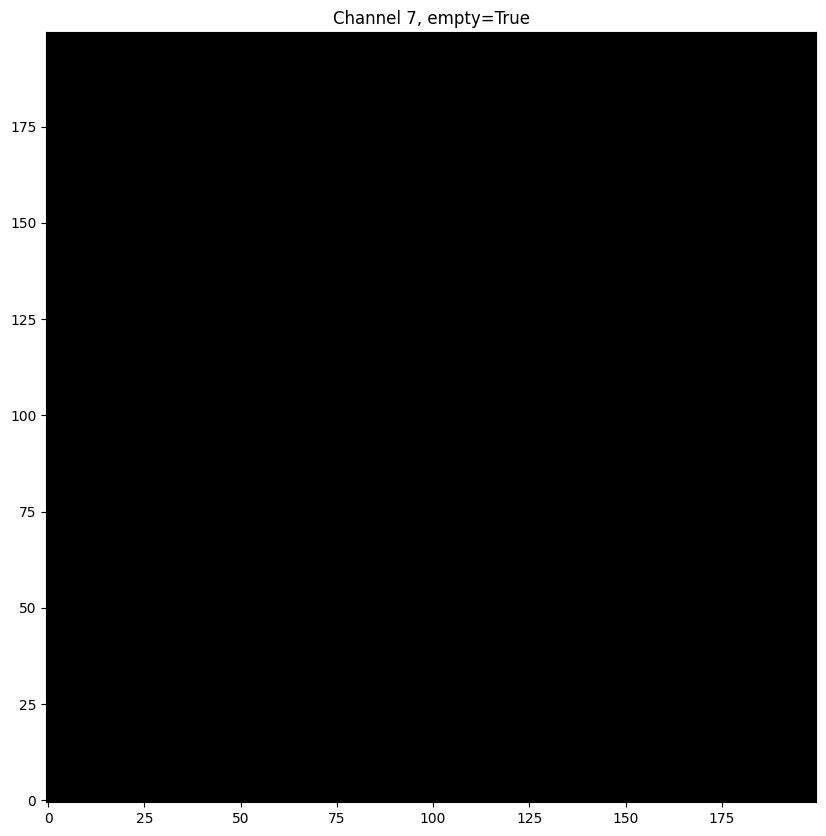

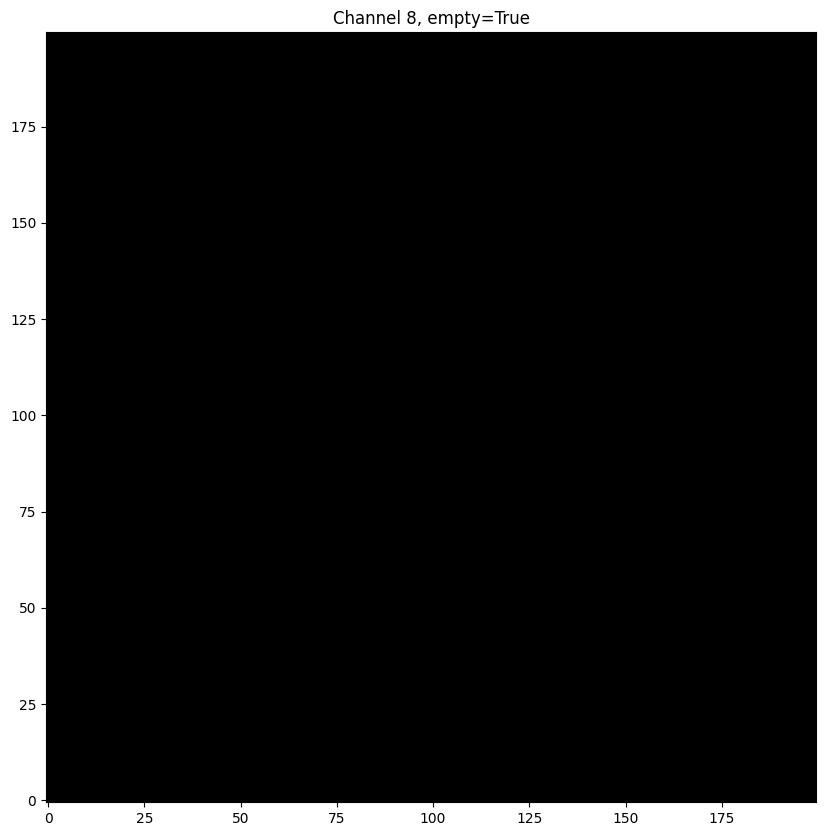

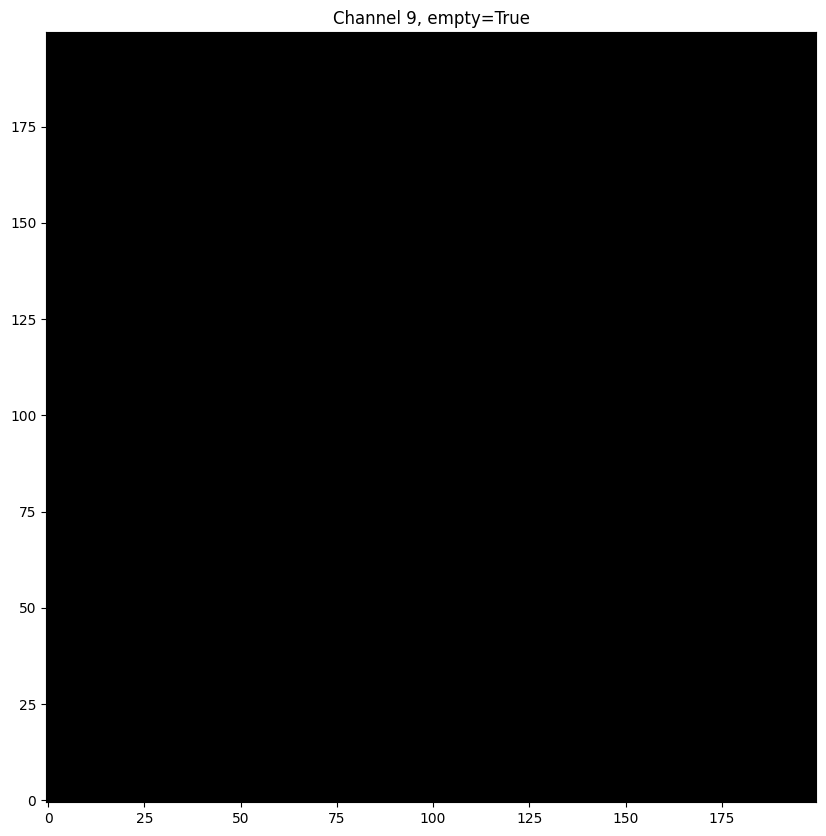

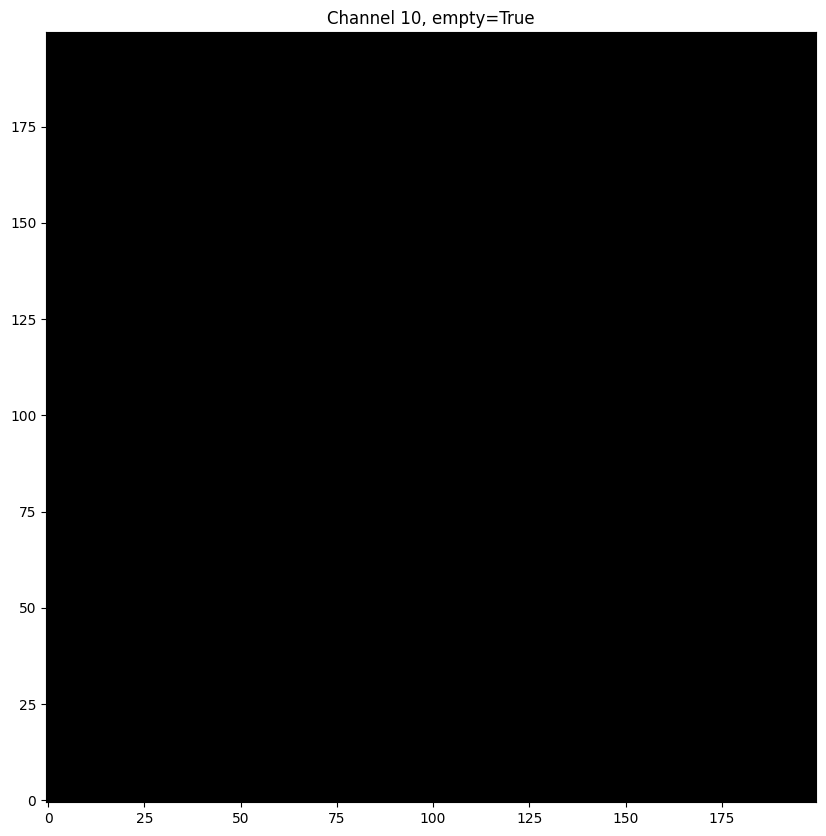

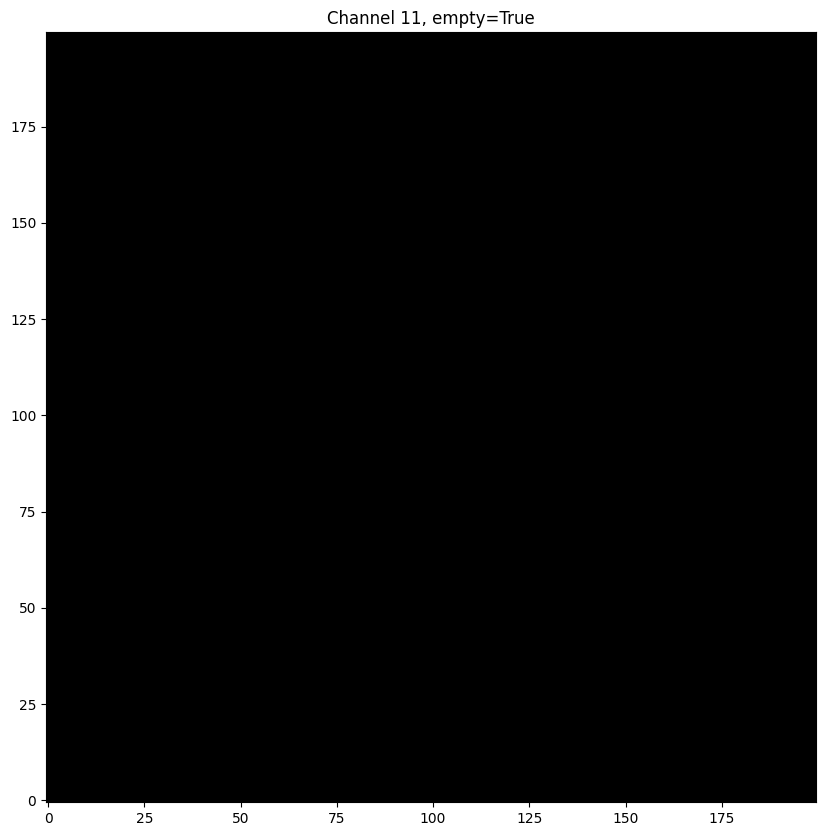

In [152]:
plot_feature_map(trl_map)

Тест на 1 балл


In [153]:
# test fails for missing file
# FileNotFoundError: [Errno 2] No such file or directory: '/content/lib/tests/data/trl_map'
# test_traffic_light_renderer(TrafficLightsRenderer)

Функция, объединяющая все рендереры

In [154]:
def render_features(features, size=render_size, resolution=0.25):
    renderers = [
        AgentRenderer(size=size, resolution=resolution),
        RoadGraphRenderer(size=size, resolution=resolution),
        TrafficLightsRenderer(size=size, resolution=resolution)
    ]

    return torch.cat(
        [
            renderer(features).to(device)
            for renderer in renderers
        ],
        dim=1
    ).to(device)


In [155]:
map = render_features(ego_space_features)

### Вcпомогательные функции отрисовки предсказаний модели

In [156]:
def plot_states(states, use_log_traj=False, batch_idx=0):
    imgs = []
    for state in states:
        imgs.append(visualization.plot_simulator_state(
            state, use_log_traj=use_log_traj, batch_idx=batch_idx))
    mediapy.show_video(imgs, fps=10)


def extract_best_mode_from_pred_component(pred, best_mode):
    return pred[np.arange(best_mode.shape[0]), best_mode]

def extract_first_timestep_from_pred(pred):
    return pred[..., 0]


# generate open loop prediction with single model run
def generate_open_loop(model, scenario, history_size=11, agent_idx=None):
    states = []

    # some tensors for slicing
    batch_range = jnp.arange(scenario.object_metadata.is_sdc.shape[0])
    control_mask = scenario.object_metadata.is_sdc
    if agent_idx:
        control_mask = jnp.zeros_like(control_mask)
        control_mask = control_mask.at[batch_range, agent_idx].set(True)
        print(f'Control agent with agent_idx = {agent_idx}')
    else:
        print(f'Control ego agent')
    control_indices = control_mask.argmax(-1)

    features, gt = scenario_to_features_gt(
        scenario,
        agent_to_predict_mask=control_mask,
        device=device
    )

    model.to(device)

    # run model
    pred = model(features)  # YOUR CODE HERE
    state = scenario

    # get best mode
    best_mode = pred['logits'].argmax(-1)  # YOUR CODE HERE

    # get best by logit predictions and convert to numpy
    new_x = extract_best_mode_from_pred_component(pred['trajectory']['x'], best_mode).detach().cpu().numpy()
    new_y = extract_best_mode_from_pred_component(pred['trajectory']['y'], best_mode).detach().cpu().numpy()
    new_vel_x = extract_best_mode_from_pred_component(pred['trajectory']['vel_x'], best_mode).detach().cpu().numpy()
    new_vel_y = extract_best_mode_from_pred_component(pred['trajectory']['vel_y'], best_mode).detach().cpu().numpy()
    new_yaw = extract_best_mode_from_pred_component(pred['trajectory']['yaw'], best_mode).detach().cpu().numpy()


    # make 10 steps to make step.timestep equal to first inference timestep
    state = datatypes.update_state_by_log(state, num_steps=10)
    assert (state.timestep == 10).all()


    for _ in range(FUTURE_STEPS):
        # copy log trajectories to sim trajectories for all objects
        state = datatypes.update_state_by_log(state, num_steps=1)

        # rewrite ego sim_trajectory by predictions
        state.sim_trajectory.x = state.sim_trajectory.x.at[batch_range, control_indices, history_size:history_size+FUTURE_STEPS].set(new_x) # YOUR CODE HERE
        state.sim_trajectory.y = state.sim_trajectory.y.at[batch_range, control_indices, history_size:history_size+FUTURE_STEPS].set(new_y)
        state.sim_trajectory.yaw = state.sim_trajectory.yaw.at[batch_range, control_indices, history_size:history_size+FUTURE_STEPS].set(new_yaw)
        state.sim_trajectory.vel_x = state.sim_trajectory.vel_x.at[batch_range, control_indices, history_size:history_size+FUTURE_STEPS].set(new_vel_x)
        state.sim_trajectory.vel_y = state.sim_trajectory.vel_y.at[batch_range, control_indices, history_size:history_size+FUTURE_STEPS].set(new_vel_y)

        state.sim_trajectory.valid = state.sim_trajectory.valid.at[batch_range, control_indices, history_size:history_size+FUTURE_STEPS].set(True)

        states.append(state)

    return states

## 3. Prediction модель [5 баллов]

Здесь мы хотим реализовать модель для предсказания агентов, использующую растровые признаки в качестве признаков карты, то есть здесь запрещено использовать векторные признаки карты и светофоров при обучении модели. При этом можно использовать векторные признаки агентов

- Реализация метрик [1 балл]
- Качество модели [4 балла]
  - min_ade=1.5, top1_ade=3.0 [4 баллов]
  - min_ade=1.7, top1_ade=3.5 [2 баллов]

Модель должна предсказывать 6 мод по 3 секунды и иметь формат выхода аналогичный с SimpleModel

Нужно приложить обучающие кривые (можно скрины) и вывод метрик на валидации


Для начала реализуем функцию подсчета метрик, нас интересуют `top1_ade` и `min_ade` для предсказываемого агента. Не забудьте учесть маску видимости агента в гт, усредняем только те таймстемпы, в которые агент наблюдался

### Описание доступных признаков

Все признаки хранятся в словаре `features` и перед подачей в модель проходят через `NormalizeSceneWrapper`, который переводит сцену в **систему координат предсказываемого агента**: начало — его позиция в последний наблюдаемый тик, ось X — вдоль его курса, ось Y — влево. Это позволяет модели работать с относительными, а не абсолютными координатами.

---

#### Векторные признаки агентов (`features['log_trajectory']`)
Форма тензоров: **`[bs, 24, 11]`** — батч × агенты × временны́е шаги истории.

| Ключ | Форма | Физический смысл |
|---|---|---|
| `x`, `y` | `[bs, 24, 11]` | Координаты центра агента в системе координат предсказываемого агента (м). `(0, 0)` — позиция целевого агента в последний тик истории. |
| `vel_x`, `vel_y` | `[bs, 24, 11]` | Скорость (м/с) в той же повёрнутой системе. |
| `yaw` | `[bs, 24, 11]` | Курс (рад). Для целевого агента в последний тик `yaw=0`. |
| `length`, `width` | `[bs, 24, 11]` | Размеры ограничивающего прямоугольника (м). |
| `valid` | `[bs, 24, 11]` | `1.0` — агент наблюдался в данный тик, `0.0` — нет. |

#### Метаданные агентов (`features['object_metadata']`)

| Ключ | Форма | Физический смысл |
|---|---|---|
| `object_types` | `[bs, 24]` | Тип агента: 0=неизвестно, 1=авто, 2=пешеход, 3=велосипедист и т.д. |
| `is_sdc` | `[bs, 24]` | `True` для ego-агента (Self-Driving Car). |

#### Маска целевого агента

| Ключ | Форма | Физический смысл |
|---|---|---|
| `agent_to_predict_mask` | `[bs, 24]` | Булева маска: ровно одна `True` на батч — целевой агент. |

---

#### Растровые признаки карты — выход `render_features(features)`
`render_features` конкатенирует три рендерера по оси каналов и возвращает тензор **`[bs, 51, 400, 400]`**.

Пространственное разрешение: **0.25 м/пиксель**, видимая область: **100×100 м** вокруг целевого агента.
Центр карты `(ix=200, iy=200)` = `(x=0, y=0)` = позиция целевого агента.

| Рендерер | Выход | Каналы (C) | Канальный состав |
|---|---|---|---|
| `AgentRenderer` | `[bs, 13, 400, 400]` | 13 | `[1, x, y, vel_x, vel_y, sin(yaw), cos(yaw), is_sdc, one_hot(type, 5)]` |
| `RoadGraphRenderer` | `[bs, 26, 400, 400]` | 26 | `[1, x, y, dir_x, dir_y, one_hot(road_type, 21)]` |
| `TrafficLightsRenderer` | `[bs, 12, 400, 400]` | 12 | `[1, x, y, one_hot(state, 9)]` |
| **`render_features` (итого)** | **`[bs, 51, 400, 400]`** | **51** | конкатенация по dim=1 |

Значения x, y, vel_x, vel_y и dir_x, dir_y в пикселях хранятся в системе координат предсказываемого агента (в метрах), то есть напрямую интерпретируемы как относительные смещения.

---

#### Запрещённые признаки (нельзя подавать напрямую в модель)

| Признак | Форма | Причина запрета |
|---|---|---|
| `features['roadgraph_points']['x/y/dir_x/dir_y/types/valid']` | `[bs, N_pts]` | Векторные признаки карты — переменная длина, произвольная топология. Без attention/GNN их нельзя подать в CNN/MLP без потери структуры. Вместо них используйте `RoadGraphRenderer`. |
| `features['log_traffic_light']['x/y/state/valid']` | `[bs, N_lights, 11]` | Аналогично — векторные признаки светофоров. Вместо них — `TrafficLightsRenderer`. |
| `features['sim_trajectory']` | `[bs, 24, 11]` | Содержит симулированное (а не наблюдённое) будущее — data leakage для задачи prediction. |

---

### Что разрешено использовать в PredictionModel

**Допустимые входы:**
1. **Растровая карта** `render_features(features)` → `[bs, 51, 400, 400]` — обрабатывается CNN.
2. **История целевого агента** `features['log_trajectory'][...][agent_to_predict_mask]` → `[bs, 11, 7]` (11 тиков × 7 признаков: x, y, vel_x, vel_y, length, width, valid) — можно подать в MLP или RNN.
3. **Тип агента** `features['object_metadata']['object_types'][agent_to_predict_mask]` → `[bs]`.

Типичная архитектура: CNN на растровой карте → глобальный пулинг или flatten → конкатенация с вектором истории → MLP → 6 мод × 30 шагов + 6 логитов.


In [157]:
agent_to_predict_mask.shape

torch.Size([8, 24])

In [158]:
def prediction_metrics(pred, gt):
    """
    Compute loss for first mode

    Args:
      pred: prediction
      gt: target

        pred = {
            'trajectory': {
                'x': traj[..., 0],
                'y': traj[..., 1],
                'yaw': torch.atan2(traj[..., 2], traj[..., 3]),
                'vel_x': traj[..., 4],
                'vel_y': traj[..., 5]
            },
            'logits': ...
        }

        gt = {
            'log_trajectory': {
                'x': ...,
                'y': ...,
                'z': ...,
                'vel_x': ...,
                'vel_y': ...,
                'yaw': ...,
                'valid': ...,
                'timestamp_micros': ...,
                'length': ...,
                'width': ...,
                'height': ...,
            }
        }

    Returns:
      loss: dict with keys `min_ade`, `top1_ade`
    """
    # YOUR CODE HERE
    agent_to_predict_mask = gt['agent_to_predict_mask'] # [bs, n_agents]
    x_gt = gt['log_trajectory']['x'][agent_to_predict_mask] # [bs, n_timesteps]
    y_gt = gt['log_trajectory']['y'][agent_to_predict_mask] # [bs, n_timesteps]
    valid = gt['log_trajectory']['valid'][agent_to_predict_mask].bool() # [bs, n_timesteps]

    x = pred['trajectory']['x'] # [bs, num_modes, n_timesteps]
    y = pred['trajectory']['y'] # [bs, num_modes, n_timesteps]
    log_probs = pred['logits'] # [bs, num_modes]

    best_mode = torch.argmax(log_probs, dim=1) # [bs]

    batch_size, _ = agent_to_predict_mask.shape

    # TODO: add valid mask
    dx = x_gt.unsqueeze(1) - x # [bs, num_modes, n_timesteps]
    dy = y_gt.unsqueeze(1) - y # [bs, num_modes, n_timesteps]
    displacement = torch.sqrt(dx * dx + dy * dy) # [bs, num_modes, n_timesteps]

    valid_mask = valid.unsqueeze(1) # [bs, 1, n_timesteps]
    n_valid = valid_mask.sum(dim=-1).clamp(min=1) # [bs, 1]
    displacement_masked = displacement * valid_mask # [bs, num_modes, n_timesteps]
    ade_per_mode = displacement_masked.mean(dim=-1) # [bs, num_modes]

    min_ade = ade_per_mode.min(dim=-1).values.mean()


    best_mode = log_probs.argmax(dim=-1) # [bs]
    top1_ade = ade_per_mode[torch.arange(batch_size), best_mode].mean() # [bs]


    return {
        'min_ade': min_ade,
        'top1_ade': top1_ade,
    }

In [159]:
features, gt = scenario_to_features_gt(scenario)
model = NormalizeSceneWrapper(SimpleModel())
pred = model(features)
prediction_metrics(pred, gt)

{'min_ade': tensor(6.0596, grad_fn=<MeanBackward0>),
 'top1_ade': tensor(6.2675, grad_fn=<MeanBackward0>)}

In [160]:
from lib.tests.tests import test_metrics

Тест на 1 балл

In [161]:
test_metrics(prediction_metrics)

Metrics test passed


Ниже класс, который будем использовать для обучения моделек

In [162]:
class PredictionModule(pl.LightningModule):
    """
    Module with methods for model training
    """
    def __init__(
        self,
        model,
        loss_components_function,
        metrics_function,
        training_shift_random_generator=lambda : 0,
        training_agent_sampler=lambda scenario: scenario.object_metadata.is_sdc,
        validation_agent_sampler=lambda scenario: scenario.object_metadata.is_sdc,
        map_points=256,
        lr=1e-3
    ):
        """
        Args:
          model: model to train
          loss_components_function:
            function that takes (pred, gt) and return dict of losses
          metrics_function:
            function that takes (pred, gt) and return dict of metrics
          training_shift_random_generator:
            function that return shift for features/gt split
            it allow us to augment dataset and get more diverse scenarios
          training_agent_sampler: function that return mask with agent of interest during training
          validation_agent_sampler: function that return mask with agent of interest during validation
        """
        super().__init__()
        self.save_hyperparameters(ignore=['model', 'loss_components_function', 'metrics_function',
                                           'training_shift_random_generator', 'training_agent_sampler',
                                           'validation_agent_sampler'])
        self.model = model
        self.loss_components_function = loss_components_function
        self.metrics_function = metrics_function
        self.training_shift_random_generator = training_shift_random_generator
        self.training_agent_sampler = training_agent_sampler
        self.validation_agent_sampler = validation_agent_sampler

        self.map_points = map_points
        self.lr = lr

    # Method to log loss
    def log_loss(self, split_name, loss, loss_components, batch_size):
        """
        Log loss to tensorboard

        Args:
          split_name: train/val
          loss: step loss
          loss_components: dict of step loss components
          batch_size: batch_size
        """
        self.log(
            f'{split_name}/epoch/loss/loss',
            loss.detach().cpu().item(),
            batch_size=batch_size,
            on_epoch=True,
            on_step=False
        )
        for k, v in loss_components.items():
            self.log(
                f'{split_name}/epoch/loss/{k}',
                v.detach().cpu().item(),
                batch_size=batch_size,
                on_epoch=True,
                on_step=False
            )

    # Method to log metrics
    def log_metrics(self, split_name, metrics, batch_size):
        """
        Log metrics to tensorboard

        Args:
          split_name: train/val
          metrics: dict of step metrics
          batch_size: batch_size
        """
        for k, v in metrics.items():
            self.log(
                f'{split_name}/epoch/{k}',
                v.detach().cpu().item(),
                batch_size=batch_size,
                on_epoch=True,
                on_step=False
            )

    # Model step
    def step(self, scenario, agent_to_predict_mask, shift=0):
        """
        Make model step

        Args:
          scenario: train/val
          agent_to_predict_mask: mask with agent to predict
          shift: shift for features

        Returns:
          (
            pred,            # model output
            gt,              # target
            loss,            # loss value
            loss_components  # loss components dict
          )
        """
        # split scenario to features and gt
        features, gt = scenario_to_features_gt(
            scenario,
            map_points=self.map_points,
            features_first_timestamp=shift,
            agent_to_predict_mask=agent_to_predict_mask,
            device=self.device)
        # apply model
        pred = self.model(features)
        # compute losses
        loss_components = self.loss_components_function(pred, gt)
        loss_weights = {
            'regression':     1.0,
            'classification': 0.5,
        }
        loss = sum(loss_components[key] * loss_weights[key] for key in loss_components.keys())
        return pred, gt, loss, loss_components

    # Validation step
    @torch.no_grad
    def validation_step(self, scenario, batch_idx):
        """
        Make validation step

        Args:
          scenario: train/val
          batch_idx: number of step

        Returns:
          loss
        """
        # sample agent to predict
        agent_to_predict_mask = self.validation_agent_sampler(scenario)

        pred, gt, loss, loss_components = self.step(
            scenario,
            agent_to_predict_mask=agent_to_predict_mask)
        self.log_loss(
            'val', loss, loss_components,
            batch_size=scenario['log_trajectory']['x'].shape[0],
        )
        self.log_metrics(
            'val', self.metrics_function(pred, gt),
            batch_size=scenario['log_trajectory']['x'].shape[0],)

        return loss

    # Training step
    def training_step(self, scenario, batch_idx):
        """
        Make training step

        Args:
          scenario: train/val
          batch_idx: number of step

        Returns:
          loss
        """
        # sample agent to predict
        agent_to_predict_mask = self.training_agent_sampler(scenario)

        pred, gt, loss, loss_components = self.step(
            scenario,
            agent_to_predict_mask=agent_to_predict_mask,
            shift=self.training_shift_random_generator())
        self.log_loss(
            'train', loss, loss_components,
            batch_size=scenario['log_trajectory']['x'].shape[0],
        )
        return loss


    def configure_optimizers(self):
        optimizer = torch.optim.AdamW(self.parameters(), lr=self.lr, weight_decay=1e-4)
        # CosineAnnealingLR only needs T_max=max_epochs, which is always known.
        # OneCycleLR requires total_steps at construction, but estimated_stepping_batches
        # returns -1 for generator datasets (like Waymax TFRecord) that have no __len__.
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer,
            T_max=self.trainer.max_epochs,
            eta_min=self.lr * 1e-3,  # decay to 0.1% of peak LR
        )
        return {
            "optimizer": optimizer,
            "lr_scheduler": {"scheduler": scheduler, "interval": "epoch"},
        }

    # Make optimizer


Ниже функции выбора агента на сцене для предсказания

In [163]:
# Sampler for prediction training, use different agents on different epochs
def random_agent_sampler(scenario):
    valid = np.asarray(scenario.log_trajectory.valid[..., 10]).copy()
    valid[scenario.object_metadata.is_sdc] = False
    agent_to_predict_mask = np.argmax(np.random.rand(*valid.shape) * valid, -1)
    mask = np.zeros(scenario.object_metadata.is_sdc.shape, dtype=bool)
    mask[np.arange(agent_to_predict_mask.shape[0]), agent_to_predict_mask] = True
    return jnp.asarray(mask)


# Sampler for prediction validation, use fixed first agent to predict
def first_agent_sampler(scenario):
    valid = np.asarray(scenario.log_trajectory.valid[..., 10]).copy()
    valid[scenario.object_metadata.is_sdc] = False
    agent_to_predict_mask = np.argmax(valid, -1)
    mask = np.zeros(scenario.object_metadata.is_sdc.shape, dtype=bool)
    mask[np.arange(agent_to_predict_mask.shape[0]), agent_to_predict_mask] = True
    return jnp.asarray(mask)


# Sampler for planning, use ego to predict
def ego_agent_sampler(scenario):
    return scenario.object_metadata.is_sdc

Реализуйте модель, которая принимает на вход растровые признаки и обучите ее

# Архитектура модели для предсказания многомодальных траекторий

## 1. Типичные ошибки и вызовы в предсказании траекторий

**Основные опасности:**
- **Mode collapse**: Модель выучивает усреднённую траекторию вместо распределения мод
- **Переобучение на прямолинейное движение**: Сложные маневры недоучены
- **Игнорирование многомодальности**: На перекрёстках несколько равновероятных траекторий
- **Утечка будущей информации**: Нереалистично высокая точность на валидации

**SOTA подходы**:
- **VectorNet** (2019): Вектоизация траекторий и графа
- **MTR** (2021): Multi-Task Representation Learning
- **MotionTransformer** (2021): Self-attention между агентами
- **Scene Transformer** (2021): Трансформер на уровне сцены
- **Wayformer** (2023): CNN + Transformer гибрид

## 2. Архитектура для V100 (1–2h обучения)

**Гибридный подход**:
- ResNet18 для карты (~11M параметров)
- MLP энкодер агента + простой attention
- Общее: ~25–35M параметров

**Захватываем SOTA идеи**:
- Вектоизация истории агента (MLP)
- Растровое кодирование сцены (CNN)
- Многомодальный выход (K=6 мод)
- Внимание к K ближайшим соседям

**Компромиссы**:
- Нет полного self-attention (дорого)
- Упрощённое внимание соседей
- ~80–90% точности из self-features достаточно

## 3. Координатные системы: карта (мир) vs агент (локально)

**Проблема**: Растровая карта — мировые координаты; агент-признаки — агент-центричны.

**Решение**:
1. Маска центра агента в CNN
2. Кросс-внимание: Query(agent_MLP) × Key/Value(CNN_features)
3. Взвешенная сумма признаков в районе агента

## 4. Взаимодействия между агентами

Self-features объясняют 80–90%; 10–20% критично для:
- Слияния (merges)
- Уступание (yielding)  
- Плотный трафик

**Используем attention над K ближайшими**: баланс точность/стоимость.


In [164]:
class PredictionModel(nn.Module):
    """
    Prediction model: takes rasterized map + agent history, outputs multimodal trajectories.

    Inputs (inside forward via `features` dict, already in target-agent coordinate frame):
      render_features(features)
        shape [bs, 51, 400, 400], float32
        Rasterized bird's-eye-view map at 0.25 m/px (100x100 m window).
        Channels: AgentRenderer(13) | RoadGraphRenderer(26) | TrafficLightsRenderer(12).

      features['log_trajectory'][...][agent_to_predict_mask]  -- target agent history
        shape [bs, 11]  per field (x, y, vel_x, vel_y, length, width, valid)
        Stack to get [bs, 11, 7] or flatten to [bs, 77].

      features['object_metadata']['object_types'][agent_to_predict_mask]
        shape [bs], int  -- agent type (0=unknown, 1=vehicle, 2=pedestrian, 3=cyclist)

    Output (same format as SimpleModel):
      {
        'trajectory': {
            'x':     [bs, n_modes, future_steps],
            'y':     [bs, n_modes, future_steps],
            'yaw':   [bs, n_modes, future_steps],
            'vel_x': [bs, n_modes, future_steps],
            'vel_y': [bs, n_modes, future_steps],
        },
        'logits': [bs, n_modes]   -- unnormalised mode confidences
      }
    All values in target-agent coordinate frame (NormalizeSceneWrapper inverts back to global).
    """

    def __init__(self, n_modes=6, future_steps=30):
        super().__init__()
        self.n_modes = n_modes
        self.future_steps = future_steps
        self.hidden_dim = 256
        self.agent_encoding_dim = 128
        self.num_neighbors = 4
        # Map feature dims after self.map_encoder. Keep in sync with the encoder block.
        self.map_feat_dim = 256
        self.map_feat_h = 50
        self.map_feat_w = 50

        # # CNN backbone: lightweight encoder for rasterized map
        # # Input: [bs, 51, 400, 400] -> Output: [bs, 256, 50, 50]
        # self.map_encoder = nn.Sequential(
        #     nn.Conv2d(51, 64, kernel_size=7, stride=2, padding=3),
        #     nn.BatchNorm2d(64),
        #     nn.ReLU(inplace=True),
        #     nn.MaxPool2d(kernel_size=3, stride=2, padding=1),
        #     nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),
        #     nn.BatchNorm2d(128),
        #     nn.ReLU(inplace=True),
        #     nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1),
        #     nn.BatchNorm2d(256),
        #     nn.ReLU(inplace=True),
        # )

        # === ResNet18 alternative ============================================
        # To swap: comment the self.map_encoder block above, uncomment below,
        # and set map_feat_dim/h/w accordingly.
        #
        # Channel-count mismatch: ResNet18's `conv1` expects 3 input channels
        # (RGB), we have 51. We replace conv1 with a fresh Conv2d(51, 64, ...)
        # using the same kernel/stride/padding so the spatial path is unchanged.
        # The new conv1 is randomly initialised — we cannot reuse ImageNet
        # weights for 51 channels directly. (A common trick is to copy the RGB
        # weights and tile/average them across the extra channels, but for 51
        # heterogeneous channels that's not meaningful, so we just init fresh.)
        # The rest of ResNet18 keeps its ImageNet weights — still a useful
        # prior for the deeper blocks even though the first layer is new.
        # Final feature map for 400x400 input: [bs, 512, 13, 13].
        #
        import torchvision
        resnet = torchvision.models.resnet18(
            weights=torchvision.models.ResNet18_Weights.DEFAULT
        )
        resnet.conv1 = nn.Conv2d(51, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.map_encoder = nn.Sequential(
            resnet.conv1, resnet.bn1, resnet.relu, resnet.maxpool,
            resnet.layer1, resnet.layer2, resnet.layer3, resnet.layer4,
        )
        self.map_feat_dim = 512
        self.map_feat_h = 7
        self.map_feat_w = 7
        # =====================================================================

        # Probe the encoder with a dummy input to get actual output dims —
        # avoids hardcoding C/H/W that must stay in sync with both input
        # resolution and encoder architecture.
        # with torch.no_grad():
        #     _dummy = torch.zeros(1, 51, render_size, render_size)
        #     _out = self.map_encoder(_dummy)
        #     self.map_feat_dim = _out.shape[1]
        #     self.map_feat_h = _out.shape[2]
        #     self.map_feat_w = _out.shape[3]
        #     print(f"Map feature dims: {self.map_feat_dim}, {self.map_feat_h}, {self.map_feat_w}")

        # Learned 2D positional encoding for map feature cells.
        # Added to map features before flattening so attention can localise.
        self.map_pos_embed = nn.Parameter(
            torch.zeros(1, self.map_feat_dim, self.map_feat_h, self.map_feat_w)
        )
        nn.init.trunc_normal_(self.map_pos_embed, std=0.02)

        # Agent type embedding (categorical 0..num_agent_types-1 -> dense vec)
        self.num_agent_types = 5
        self.agent_type_embed_dim = 8
        self.agent_type_embedding = nn.Embedding(
            self.num_agent_types, self.agent_type_embed_dim
        )

        # MLP encoder for agent history (self-features)
        # Input: [bs, 11*7 + agent_type_embed_dim] -> Output: [bs, agent_encoding_dim]
        self.agent_encoder = nn.Sequential(
            nn.Linear(11 * 7 + self.agent_type_embed_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(256, self.agent_encoding_dim),
        )

        # MLP encoder for neighbor trajectories
        # Each neighbor: 11 timesteps * 7 features (x, y, vx, vy, length, width, valid)
        self.neighbor_encoder = nn.Sequential(
            nn.Linear(11 * 7, 128),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(128, self.agent_encoding_dim),
        )

        # Projection from agent encoding to map attention query space.
        # Replaces the previous cat([q, q]) hack with a proper learned projection.
        self.agent_to_map_query = nn.Linear(self.agent_encoding_dim, self.map_feat_dim)

        # Spatial attention for bridging map features and agent position
        # Handles coordinate system mismatch: agent is at center of agent-centric frame
        # Agent query attends to spatial map features to extract relevant context
        self.map_attention = nn.MultiheadAttention(
            embed_dim=self.map_feat_dim,
            num_heads=4,
            dropout=0.1,
            batch_first=True
        )

        # Neighbor interaction attention: agent attends to encoded neighbor features
        # This captures agent-agent interactions (merges, yielding, dense traffic)
        self.neighbor_attention = nn.MultiheadAttention(
            embed_dim=self.agent_encoding_dim,
            num_heads=4,
            dropout=0.1,
            batch_first=True
        )

        # Fusion MLP: combine map features, agent features, and neighbor interactions
        fusion_input_dim = self.map_feat_dim + self.agent_encoding_dim + self.agent_encoding_dim
        self.fusion = nn.Sequential(
            nn.Linear(fusion_input_dim, 512),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(512, 512),
            nn.ReLU(),
        )

        # Trajectory decoder: predict K modes with future_steps timesteps
        # Output: [K * future_steps * 6] for trajectories + [K] for logits
        self.trajectory_head = nn.Sequential(
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, self.n_modes * self.future_steps * 6 + self.n_modes),
        )

    def forward(self, features):
        bs = features['log_trajectory']['x'].shape[0]
        num_agents = features['log_trajectory']['x'].shape[1]

        # ========== Encode rasterized map via CNN ==========
        # Input map is already in agent-centric frame with agent at center
        feature_map = render_features(features)  # [bs, 51, 400, 400]
        map_features = self.map_encoder(feature_map)  # [bs, 256, 50, 50]

        # ========== Encode agent self-features (history in agent-centric frame) ==========
        agent_history = torch.stack([
            features['log_trajectory']['x'],
            features['log_trajectory']['y'],
            features['log_trajectory']['vel_x'],
            features['log_trajectory']['vel_y'],
            features['log_trajectory']['length'],
            features['log_trajectory']['width'],
            features['log_trajectory']['valid'],
        ], axis=-1)  # [bs, num_agents, 11, 7]

        target_agent_mask = features['agent_to_predict_mask']  # [bs, num_agents]
        target_agent = agent_history[target_agent_mask]  # [bs, 11, 7]
        agent_type = features['object_metadata']['object_types'][target_agent_mask]  # [bs]

        # Embed categorical agent_type (instead of feeding raw int into a Linear)
        agent_type_idx = torch.clamp(agent_type.long(), min=0, max=self.num_agent_types - 1)
        agent_type_emb = self.agent_type_embedding(agent_type_idx)  # [bs, agent_type_embed_dim]

        agent_input = torch.cat([
            target_agent.reshape(bs, -1),  # Flatten: [bs, 77]
            agent_type_emb,                # [bs, agent_type_embed_dim]
        ], dim=-1)  # [bs, 77 + agent_type_embed_dim]

        agent_feat = self.agent_encoder(agent_input)  # [bs, 128]

        # ========== Bridge map and agent via spatial attention ==========
        # Add learned positional embedding so attention can distinguish cells
        map_features = map_features + self.map_pos_embed  # [bs, C, H, W]

        # Flatten and transpose map features for attention
        # Map features: [bs, C, H, W] -> [bs, H*W, C]
        map_feat_flat = map_features.reshape(bs, self.map_feat_dim, -1).transpose(1, 2)

        # Agent query: project agent features to map feature dimension via learned Linear
        agent_query = self.agent_to_map_query(agent_feat).unsqueeze(1)  # [bs, 1, map_feat_dim]

        # Attention: agent attends to all spatial regions of the map
        map_context, _ = self.map_attention(
            agent_query, map_feat_flat, map_feat_flat
        )  # [bs, 1, map_feat_dim]
        map_context = map_context.squeeze(1)  # [bs, map_feat_dim]

        # ========== Encode neighbor trajectories and apply attention ==========
        # Vectorized neighbor selection + gather
        neighbor_trajectories_flat = agent_history.reshape(bs, num_agents, -1)  # [bs, num_agents, 77]

        # Select K nearest neighbors by distance (L2 distance of last positions)
        # In agent-centric frame the target agent sits at (0,0), so distance = ||last_pos||
        agent_last_pos = agent_history[target_agent_mask, -1, :2]  # [bs, 2]
        all_last_pos = agent_history[..., -1, :2]                  # [bs, num_agents, 2]

        distances = torch.norm(
            all_last_pos - agent_last_pos.unsqueeze(1), dim=-1
        )  # [bs, num_agents]

        # Mask out (a) the target agent itself and (b) invalid agents at the last tick.
        # Invalid agents are padding; selecting them would feed garbage into attention.
        last_valid = features['log_trajectory']['valid'][..., -1].bool()  # [bs, num_agents]
        invalid_mask = target_agent_mask | (~last_valid)
        distances_masked = distances.masked_fill(invalid_mask, float('inf'))

        K = min(self.num_neighbors, num_agents - 1)
        # `topk` of the negated distances == K smallest. Use `largest=False` directly for clarity.
        _, neighbor_indices = torch.topk(
            distances_masked, k=K, dim=1, largest=False
        )  # [bs, K]

        # Vectorized gather: index neighbor_trajectories_flat along dim=1
        # idx shape must match the gather source except along dim=1: [bs, K, feat_dim]
        feat_dim = neighbor_trajectories_flat.shape[-1]
        idx = neighbor_indices.unsqueeze(-1).expand(-1, -1, feat_dim)  # [bs, K, 77]
        neighbor_features = torch.gather(neighbor_trajectories_flat, 1, idx)  # [bs, K, 77]

        # Zero out neighbors whose distance was inf (i.e. no valid neighbor existed).
        # Without this, padded/invalid neighbors that survived topk would inject noise.
        gathered_dist = torch.gather(distances_masked, 1, neighbor_indices)  # [bs, K]
        valid_neighbor_mask = torch.isfinite(gathered_dist).unsqueeze(-1).float()  # [bs, K, 1]
        neighbor_features = neighbor_features * valid_neighbor_mask

        # Encode each neighbor trajectory
        neighbor_feat_encoded = self.neighbor_encoder(neighbor_features)  # [bs, K, 128]

        # Neighbor attention: agent attends to encoded neighbors
        # This captures interactions (merges, yielding, dense traffic)
        neighbor_attended, _ = self.neighbor_attention(
            agent_feat.unsqueeze(1),  # Query: [bs, 1, 128]
            neighbor_feat_encoded,     # Key/Value: [bs, K, 128]
            neighbor_feat_encoded
        )  # [bs, 1, 128]
        neighbor_context = neighbor_attended.squeeze(1)  # [bs, 128]

        # ========== Fuse all features ==========
        fused = self.fusion(torch.cat([map_context, agent_feat, neighbor_context], dim=-1))  # [bs, 512]

        # ========== Predict multimodal trajectories ==========
        output = self.trajectory_head(fused)  # [bs, n_modes*future_steps*6 + n_modes]

        logits = output[..., -self.n_modes:]  # [bs, n_modes]
        traj_raw = output[..., :-self.n_modes]  # [bs, n_modes*future_steps*6]
        traj = traj_raw.reshape(bs, self.n_modes, self.future_steps, 6)

        return {
            'trajectory': {
                'x': traj[..., 0],
                'y': traj[..., 1],
                'yaw': torch.atan2(traj[..., 2], traj[..., 3]),
                'vel_x': traj[..., 4],
                'vel_y': traj[..., 5],
            },
            'logits': logits,
        }


Реализуйте лоссы

In [165]:
def prediction_loss(pred, gt):
    """
    Multimodal Winner-Takes-All (WTA) trajectory loss.

    For each example:
      1. Find the best mode (lowest ADE to GT) — the "winner"
      2. Regress x/y only on that winner mode (WTA avoids mode collapse)
      3. Classify logits with cross-entropy, label = winner mode index

    Args:
      pred: {
        'trajectory': {'x': [bs, n_modes, T], 'y': [bs, n_modes, T], ...},
        'logits': [bs, n_modes]
      }
      gt: {
        'agent_to_predict_mask': [bs, num_agents],
        'log_trajectory': {'x': [bs, num_agents, T], 'y': [...], 'valid': [...], ...}
      }

    Returns:
      dict with keys 'regression' and 'classification'
    """
    agent_to_predict_mask = gt['agent_to_predict_mask']   # [bs, num_agents]
    x_gt     = gt['log_trajectory']['x'][agent_to_predict_mask]       # [bs, T]
    y_gt     = gt['log_trajectory']['y'][agent_to_predict_mask]       # [bs, T]
    yaw_gt   = gt['log_trajectory']['yaw'][agent_to_predict_mask]     # [bs, T]
    vx_gt    = gt['log_trajectory']['vel_x'][agent_to_predict_mask]   # [bs, T]
    vy_gt    = gt['log_trajectory']['vel_y'][agent_to_predict_mask]   # [bs, T]
    valid    = gt['log_trajectory']['valid'][agent_to_predict_mask].bool()  # [bs, T]

    x_pred   = pred['trajectory']['x']      # [bs, n_modes, T]
    y_pred   = pred['trajectory']['y']      # [bs, n_modes, T]
    yaw_pred = pred['trajectory']['yaw']    # [bs, n_modes, T]
    vx_pred  = pred['trajectory']['vel_x']  # [bs, n_modes, T]
    vy_pred  = pred['trajectory']['vel_y']  # [bs, n_modes, T]
    logits   = pred['logits']               # [bs, n_modes]

    bs = x_pred.shape[0]

    # Per-mode ADE over valid timesteps -> pick winner (using x,y only, the metric we evaluate on)
    valid_mask  = valid.unsqueeze(1).float()           # [bs, 1, T]
    dx          = x_gt.unsqueeze(1) - x_pred           # [bs, n_modes, T]
    dy          = y_gt.unsqueeze(1) - y_pred
    dist        = torch.sqrt(dx**2 + dy**2 + 1e-8)     # [bs, n_modes, T]
    ade_per_mode = (dist * valid_mask).sum(-1) / valid_mask.sum(-1).clamp(min=1)  # [bs, n_modes]
    best_mode   = ade_per_mode.argmin(dim=-1)          # [bs]

    # Regression loss only on the best mode (WTA: gradients only through winner)
    idx = torch.arange(bs, device=x_pred.device)
    x_best   = x_pred[idx, best_mode]      # [bs, T]
    y_best   = y_pred[idx, best_mode]
    yaw_best = yaw_pred[idx, best_mode]
    vx_best  = vx_pred[idx, best_mode]
    vy_best  = vy_pred[idx, best_mode]

    v       = valid.float()
    n_valid = v.sum().clamp(min=1)

    def masked_smooth_l1(pred_, gt_):
        return F.smooth_l1_loss(pred_ * v, gt_ * v, reduction='sum') / n_valid

    # x,y are the primary signal; yaw and velocity are auxiliary regression heads
    # so they don't dominate the loss but still get learned (avoids garbage values
    # during open-loop rollout that feeds yaw/vel back to the simulator).
    pos_loss = masked_smooth_l1(x_best, x_gt) + masked_smooth_l1(y_best, y_gt)

    # yaw is angular -> wrap residual into [-pi, pi] before smooth_l1
    yaw_diff = yaw_best - yaw_gt
    yaw_diff_wrapped = torch.atan2(torch.sin(yaw_diff), torch.cos(yaw_diff))
    yaw_loss = (F.smooth_l1_loss(
        yaw_diff_wrapped * v, torch.zeros_like(yaw_diff_wrapped), reduction='sum'
    ) / n_valid)

    vel_loss = masked_smooth_l1(vx_best, vx_gt) + masked_smooth_l1(vy_best, vy_gt)

    reg_loss = pos_loss + 0.1 * yaw_loss + 0.1 * vel_loss

    # Classification loss: teach logits to rank the winner highest
    cls_loss = F.cross_entropy(logits, best_mode.detach())

    return {
        'regression':     reg_loss,
        'classification': cls_loss,
    }


In [166]:
def get_notebook_name():
    import os
    from IPython import get_ipython
    
    # Get the current working directory
    cwd = os.getcwd()
    
    # Try to get the notebook name from the IPython kernel
    ip = get_ipython()
    if ip and 'kernel' in ip.config:
        notebook_name = ip.kernel.connection_file.split('-')[-1]
        full_path = os.path.join(cwd, notebook_name)
    else:
        # Fallback: list .ipynb files in current directory
        ipynb_files = [f for f in os.listdir(cwd) if f.endswith('.ipynb')]
        if ipynb_files:
            full_path = os.path.join(cwd, ipynb_files[0])
        else:
            full_path = cwd  # fallback if no .ipynb file found
    
    return full_path


def start_tensorboard():
    # now on the machine X from which you are being connected create reverse tunnel to the tensorboard:
    # ssh -N -L 6006:127.0.0.1:6006 gpu2
    tb_process = subprocess.Popen([
        'tensorboard',
        '--logdir=tb_logs/',
        '--host=127.0.0.1',
        '--port=6006'
    ])
    
    print("✓ TensorBoard started: http://127.0.0.1:6006")
    print("SSH tunnel: ssh -N -L 6006:127.0.0.1:6006 gpu2\n")


In [ ]:
# %reload_ext tensorboard
# # %tensorboard --logdir=tb_logs/
# %tensorboard --logdir=tb_logs/ --host 127.0.0.1 --port 6006
# # now on the machine X from which you are being connected create reverse tunnel to the tensorboard:
# # ssh -N -L 6006:127.0.0.1:6006 gpu2

#### training / validation curves

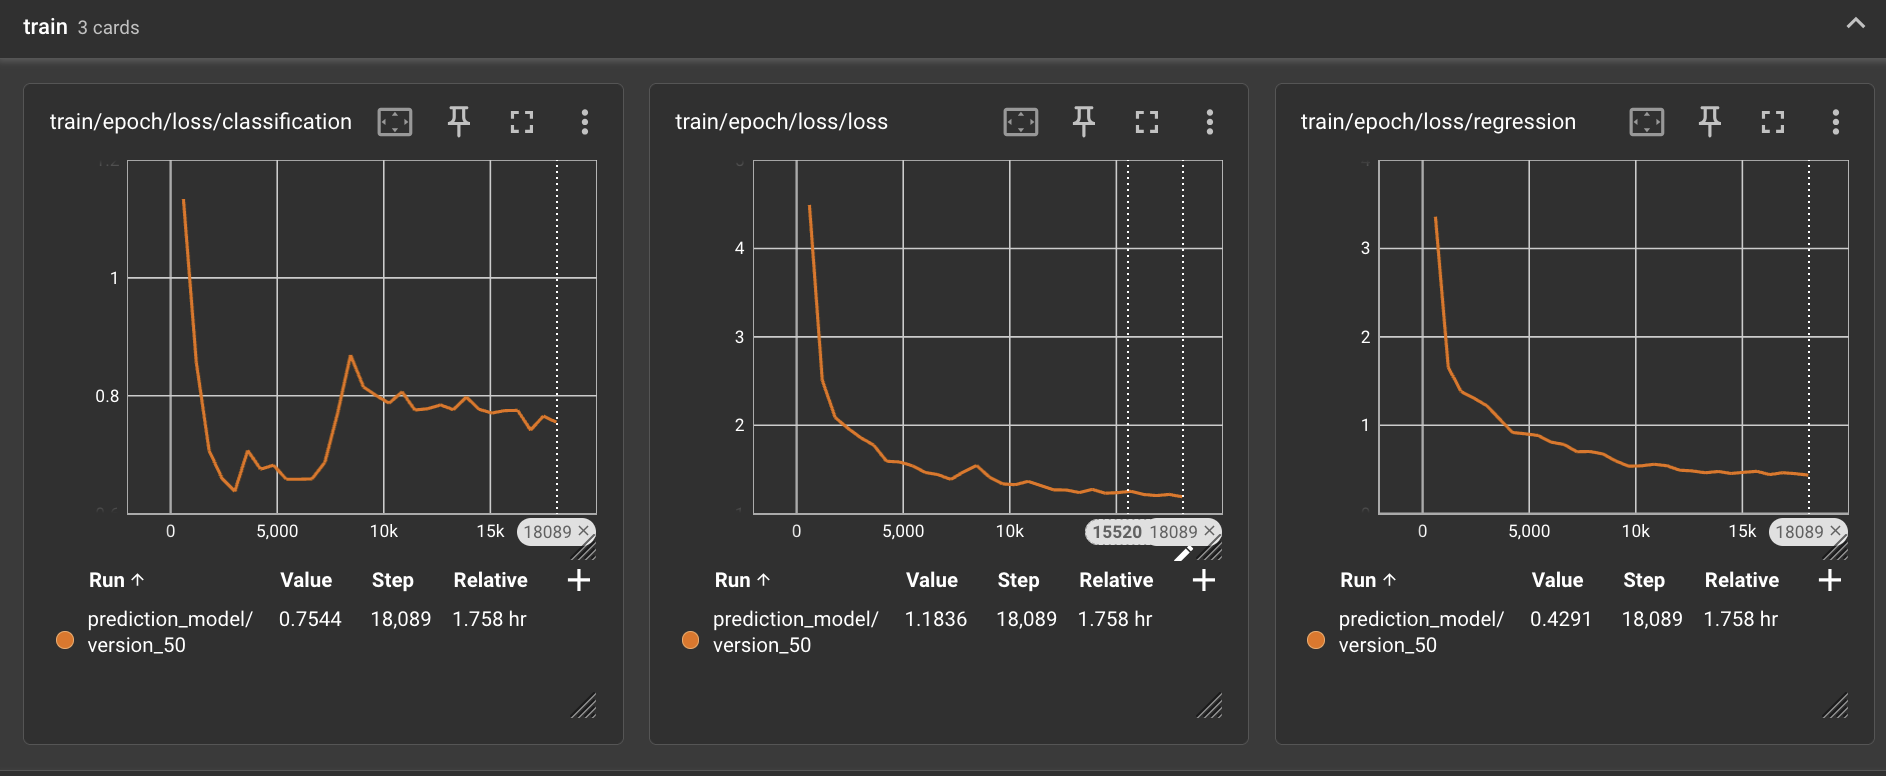
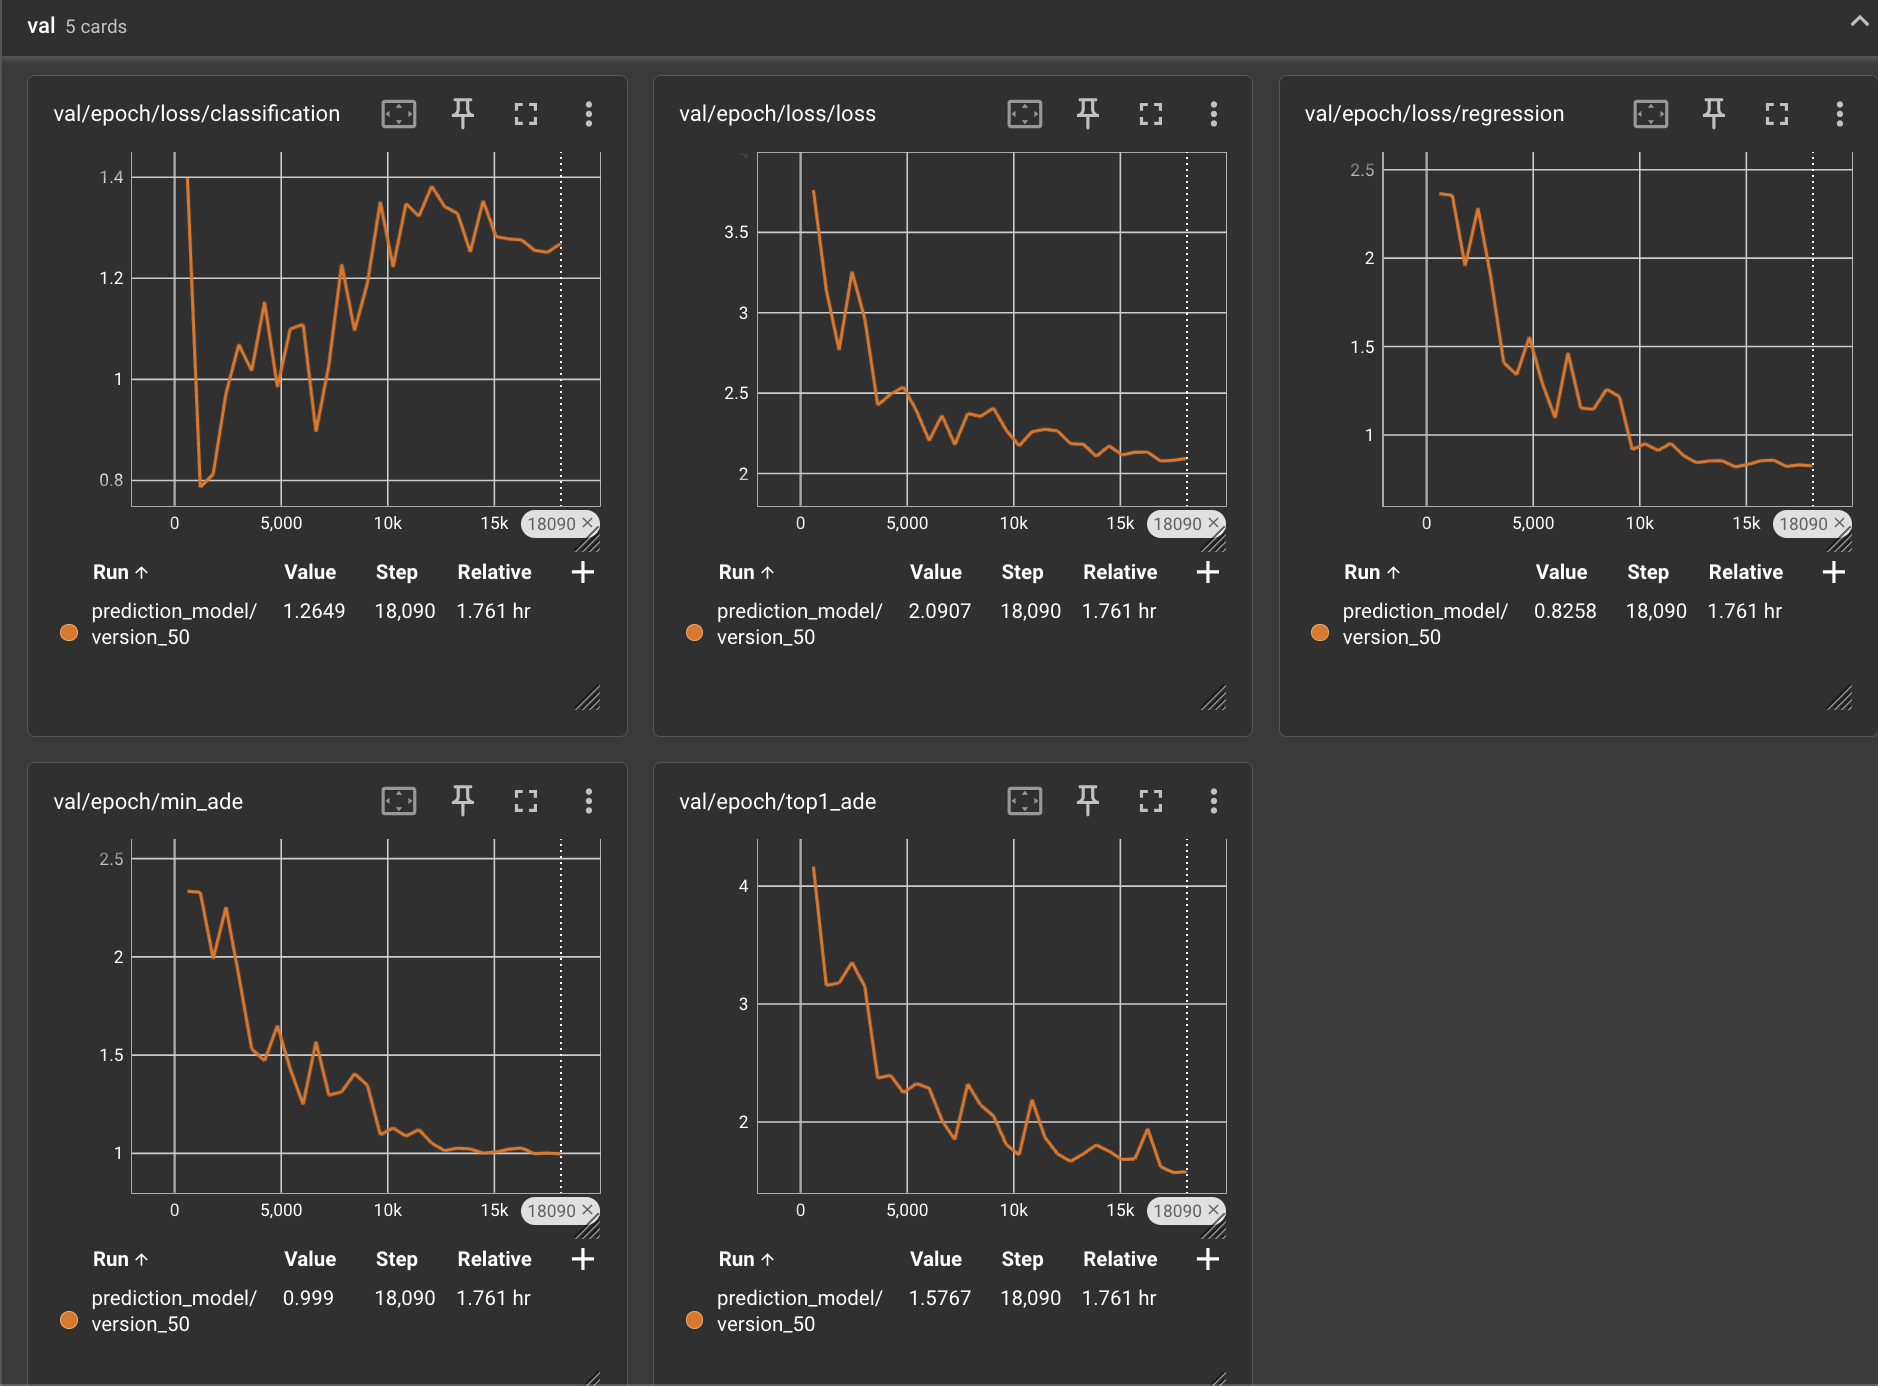

In [167]:
torch.cuda.empty_cache()

In [ ]:
prediction_model = NormalizeSceneWrapper(PredictionModel(future_steps=FUTURE_STEPS))

prediction = PredictionModule(
    model=prediction_model,
    loss_components_function=prediction_loss,
    metrics_function=prediction_metrics,
    training_shift_random_generator=lambda : 0,  # use 0 because agent can be invalid in other frames
    training_agent_sampler=random_agent_sampler,
    validation_agent_sampler=first_agent_sampler,
    lr=3e-6,
    map_points=2048
)
prediction = prediction.to(device)
logger = TensorBoardLogger("tb_logs", name="prediction_model")

run_tag = datetime.now().strftime("%Y%m%d_%H%M%S")
ckpt_dir = f'checkpoints/run_{run_tag}'
os.makedirs(ckpt_dir, exist_ok=True)
# shutil.copy(__file__, os.path.join(ckpt_dir, 'prediction_model.py'))
shutil.copy(get_notebook_name(), os.path.join(ckpt_dir, 'prediction_model.ipynb'))

checkpoint_callback = ModelCheckpoint(
    dirpath=ckpt_dir,
    filename='best-{epoch:02d}-{val/epoch/min_ade:.2f}',
    monitor='val/epoch/min_ade',
    mode='min',
    save_top_k=3,
    verbose=True
)

# TQDMProgressBar avoids the rich.jupyter recursion crash that the default
# RichProgressBar triggers under jupyter-in-browser (StagingError: maximum
# recursion depth exceeded inside rich.console._check_buffer).
trainer = pl.Trainer(
    logger=logger,
    log_every_n_steps=1,
    gradient_clip_val=0.5,
    max_epochs=30,
    accelerator=device,
    callbacks=[checkpoint_callback, TQDMProgressBar()],
    # precision="16-mixed",          # halves activation memory on V100
    # accumulate_grad_batches=2,     # effective batch = batch_dims * this
)


In [ ]:
trainer.fit(model=prediction, train_dataloaders=train_dataset, val_dataloaders=val_dataset)
print(f"Best model saved to: {checkpoint_callback.best_model_path}")

In [ ]:
trainer.validate(model=prediction, dataloaders=val_dataset)

In [168]:
def load_prediction_from_ckpt(ckpt_path, *, device=device):
    """
    Reconstruct PredictionModule + its weights from a Lightning checkpoint.

    Lightning's ModelCheckpoint saves only the state_dict (+ hparams), NOT the
    model class itself. So we rebuild the same wrapper/model graph here and
    load the weights into it. Anything you pass to PredictionModule.__init__
    that ISN'T a hparam (model, loss_components_function, metrics_function,
    samplers, ...) has to be supplied again — same as at training time.
    """
    prediction_model = NormalizeSceneWrapper(PredictionModel(future_steps=FUTURE_STEPS))

    prediction = PredictionModule.load_from_checkpoint(
        ckpt_path,
        # non-hparam ctor args — must match training-time wiring
        model=prediction_model,
        loss_components_function=prediction_loss,
        metrics_function=prediction_metrics,
        training_shift_random_generator=lambda: 0,
        training_agent_sampler=random_agent_sampler,
        validation_agent_sampler=first_agent_sampler,
        map_location=device,
    )
    prediction.eval()
    prediction.to(device)
    return prediction


## usage:
# ckpt_path = checkpoint_callback.best_model_path
## ...or hard-code a path from disk:
# ckpt_path = 'checkpoints/run_20260528_235903/best-epoch=12-val/epoch/min_ade=1.43.ckpt'

ckpt_path = 'checkpoint_prediction/best-epoch=29-val/epoch/min_ade=1.00.ckpt'
prediction = load_prediction_from_ckpt(ckpt_path)

# now you can validate / open-loop / plot:
trainer.validate(model=prediction, dataloaders=val_dataset)

Validation: |                                                                                                 …

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Validate metric        ┃         DataLoader 0          ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ val/epoch/loss/classification │      1.2697224617004395       │
│      val/epoch/loss/loss      │       1.452772617340088       │
│   val/epoch/loss/regression   │      0.8179112672805786       │
│       val/epoch/min_ade       │      0.9931047558784485       │
│      val/epoch/top1_ade       │      1.5789204835891724       │
└───────────────────────────────┴───────────────────────────────┘

[{'val/epoch/loss/loss': 1.452772617340088,
  'val/epoch/loss/regression': 0.8179112672805786,
  'val/epoch/loss/classification': 1.2697224617004395,
  'val/epoch/min_ade': 0.9931047558784485,
  'val/epoch/top1_ade': 1.5789204835891724}]

In [169]:
# predict agent with idx == 1
scenario = next(iter(val_dataset))
states = generate_open_loop(prediction.model, scenario, agent_idx=1)

Control agent with agent_idx = 1


In [170]:
plot_states(states, batch_idx=0)

This browser does not support the video tag.


In [171]:
plot_states(states, batch_idx=1)

This browser does not support the video tag.


## 4. Planning модель [7 баллов]

Реализуйте модель, которая использует векторное представление карты для планирования эго-траектории. Для обработки светофоров можно использовать cross_attention светофоров на контролируемые лейны.

Модель должна предсказывать 6 мод по 3 секунды и иметь формат выхода аналогичный с SimpleModel

Таргетные метрики на валидации:
- min_ade=0.6, top1_ade=1.5 [7 баллов]
- min_ade=0.7, top1_ade=1.75 [5 баллов]
- min_ade=0.8, top1_ade=2.0 [3 балла]

Нужно приложить обучающие кривые (можно скрины) и вывод метрик на валидации

Сохраните чекпоинт для следующей ДЗ

In [ ]:
class PlanningModel(nn.Module):
    def __init__(self, n_modes=6, future_steps=30):
        """
        Args:
          model: model to wrap
        """
        super().__init__()
        self.n_modes = n_modes
        self.future_steps = future_steps

        # YOUR CODE HERE


    def forward(self, features):
        # YOUR CODE HERE

In [ ]:
model = NormalizeSceneWrapper(PlanningModel(future_steps=FUTURE_STEPS))
pred = model(features)

Реализуйте лосс


In [ ]:
def planner_loss(pred, gt):
    """
    Compute loss for first mode

    Args:
      pred: prediction
      gt: target

    Returns:
      loss: dict with loss
    """

    # YOUR CODE HERE

    return {

    }


In [ ]:
%reload_ext tensorboard
%tensorboard --logdir=tb_logs/

Инициализируем модуль и тренера

In [ ]:
planner_model = NormalizeSceneWrapper(PlanningModel(future_steps=FUTURE_STEPS))

planner = PredictionModule(
    model=planner_model,
    loss_components_function=planner_loss,
    metrics_function=prediction_metrics,
    training_shift_random_generator=lambda : np.random.randint(0, 80 - FUTURE_STEPS + 1),
    training_agent_sampler=ego_agent_sampler,
    validation_agent_sampler=ego_agent_sampler,
    lr=5e-4
)
planner = planner.to(device)
logger = TensorBoardLogger("tb_logs", name="planner_model")

trainer = pl.Trainer(logger=logger, log_every_n_steps=1, gradient_clip_val=0.5)

Запускаем обучение

In [ ]:
trainer.fit(model=planner, train_dataloaders=train_dataset, val_dataloaders=val_dataset)

In [ ]:
trainer.validate(model=planner, dataloaders=val_dataset)

In [ ]:
# predict ego
states = generate_open_loop(planner.model, scenario)

In [ ]:
plot_states(states, batch_idx=0)

In [ ]:
plot_states(states, batch_idx=1)